In [99]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install arabic-reshaper python-bidi

import analysis # Your initial import
import importlib

importlib.reload(analysis)

import os
import json
import warnings
warnings.filterwarnings('ignore')

In [100]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

# Set a font that supports Arabic (use one available on your system)
plt.rcParams['font.family'] = 'Arial'  # or 'Tahoma', 'Times New Roman', 'Simplified Arabic'
plt.rcParams['axes.unicode_minus'] = False

# Function to reshape Arabic text for display
def arabic_text(text):
    """Reshape Arabic text for proper display in matplotlib"""
    if pd.isna(text):
        return ''
    text = str(text)
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

In [101]:
erms_melted_mr = pd.read_csv('melted_data\erms_melted_mr.csv', encoding='utf-8-sig', parse_dates=['survey_date'])
print('ERMS multiple response data loaded successfully!', erms_melted_mr.shape)

erms_melted_sr = pd.read_csv('melted_data\erms_melted_sr.csv', encoding='utf-8-sig', parse_dates=['survey_date'])
print('ERMS single response data loaded successfully!', erms_melted_sr.shape)

cust_melted_mr = pd.read_csv('melted_data\cust_mr_melted.csv', encoding='utf-8-sig', parse_dates=['survey_date'])
print('Customer multiple response data loaded successfully!', cust_melted_mr.shape)

cust_melted_sr = pd.read_csv('melted_data\cust_sr_melted.csv', encoding='utf-8-sig', parse_dates=['survey_date'])
print('Customer single response data loaded successfully!', cust_melted_sr.shape)


ERMS multiple response data loaded successfully! (18115, 11)
ERMS single response data loaded successfully! (6156, 11)
Customer multiple response data loaded successfully! (2682, 11)
Customer single response data loaded successfully! (1980, 11)


In [102]:
erms_mr = erms_melted_mr['question'].nunique()
erms_sr = erms_melted_sr['question'].nunique()

cust_sr = cust_melted_sr['question'].nunique()
cust_mr = cust_melted_mr['question'].nunique()

print(erms_mr,',', erms_sr,',', cust_sr,',', cust_mr)

87 , 37 , 6 , 13


In [103]:
erms_mr_questions = erms_melted_mr['question'].unique()
erms_sr_questions = erms_melted_sr['question'].unique()

cust_sr_questions = cust_melted_sr['question'].unique()
cust_mr_questions = cust_melted_mr['question'].unique()

print(erms_mr_questions.dtype, erms_sr_questions.dtype, cust_sr_questions.dtype, cust_mr_questions.dtype)

object object object object


In [104]:
erms_mr_questions = erms_mr_questions.tolist()
erms_sr_questions = erms_sr_questions.tolist()

cust_sr_questions = cust_sr_questions.tolist()
cust_mr_questions = cust_mr_questions.tolist()

In [105]:
# Analyze only specific questions
questions_to_analyze = [
    'service_type',
    'income_changed_after_support',
    'has_competitors'
]

print("Analyzing selected questions only...")
for question in questions_to_analyze:
    if question in erms_sr_questions:
        analyze_question(erms_melted_sr, question, 'SR')
    elif question in erms_mr_questions:
        analyze_question(erms_melted_mr, question, 'MR')

Analyzing selected questions only...


In [106]:
# Quick summary of all questions
def quick_summary(df, questions_list, label):
    """Generate quick summary for all questions"""
    print(f"\n{'=' * 80}")
    print(f"{label} - SUMMARY")
    print(f"{'=' * 80}\n")
    
    summary_data = []
    
    for question in questions_list:
        q_data = df[df['question'] == question]
        summary_data.append({
            'Question': question[:60] + '...' if len(question) > 60 else question,
            'Total': len(q_data),
            'Valid': q_data['response'].notna().sum(),
            'Missing': q_data['response'].isna().sum(),
            'Response Rate': f"{q_data['response'].notna().sum() / len(q_data) * 100:.1f}%",
            'Unique Values': q_data['response'].nunique()
        })
    
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    return summary_df

# Generate summaries
sr_summary = quick_summary(erms_melted_sr, erms_sr_questions, "SINGLE RESPONSE")
mr_summary = quick_summary(erms_melted_mr, erms_mr_questions, "MULTIPLE RESPONSE")


SINGLE RESPONSE - SUMMARY



,Question,Total,Valid,Missing,Response Rate,Unique Values
0,business_operation_duration,295,295,0,100.0%,5
1,income_sources_option_5,295,295,0,100.0%,4
2,added_new_services_after_adra,295,295,0,100.0%,2
3,market_price_changed_2_years,295,295,0,100.0%,1
4,income_change_after_support,295,295,0,100.0%,3
5,employees_count_before,46,46,0,100.0%,4
6,work_hours_per_day_before,46,46,0,100.0%,10
7,work_days_per_week_before,46,46,0,100.0%,6
8,work_months_per_year_before,46,46,0,100.0%,5
9,employees_count_after,46,46,0,100.0%,7



MULTIPLE RESPONSE - SUMMARY



,Question,Total,Valid,Missing,Response Rate,Unique Values
0,geographic_scope_village,295,295,0,100.0%,2
1,geographic_scope_neighborhood,295,295,0,100.0%,2
2,geographic_scope_district,295,295,0,100.0%,2
3,geographic_scope_governorate,295,295,0,100.0%,2
4,profession_choice_higher_profit,295,295,0,100.0%,2
...,...,...,...,...,...,...
82,price_change_reason_market_access,292,292,0,100.0%,2
83,price_change_reason_security_deterioration,292,292,0,100.0%,2
84,interruption_impact_sole_provider,295,295,0,100.0%,2
85,interruption_impact_trust_building,295,295,0,100.0%,2



################################################################################
# SINGLE RESPONSE QUESTIONS - EDA
################################################################################

QUESTION: business_operation_duration

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 5

📈 Response Distribution:
response
4    246
5     31
6     15
7      2
9      1
Name: count, dtype: int64


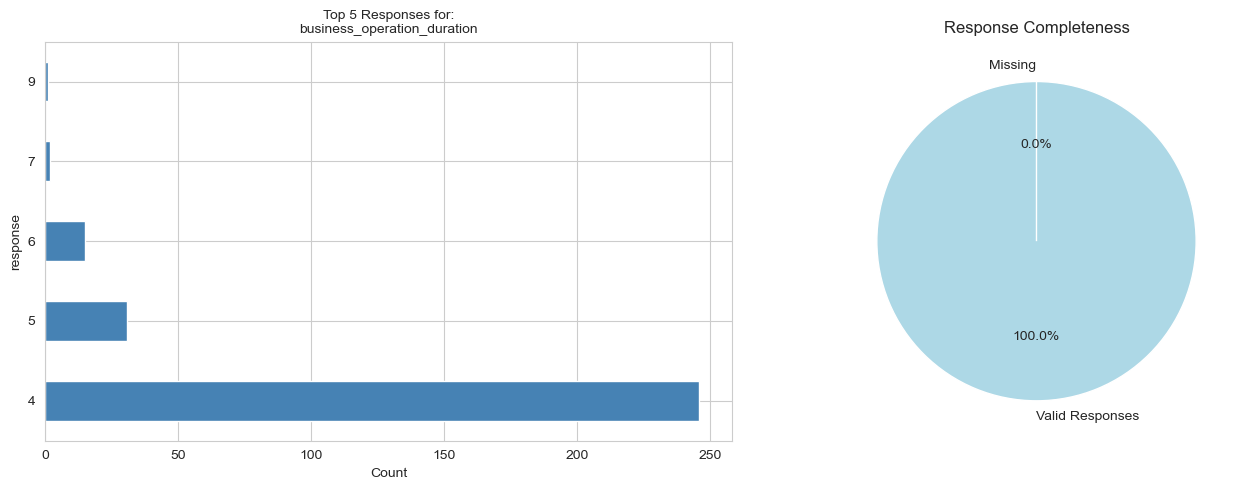


🗺️ Distribution by District:
response   4   5  6  7  9
district                 
Aldhalea  16   0  0  0  0
Khanfir   93  27  9  1  0
Radfan    23   0  0  0  0
Tuban     46   0  0  0  0
Zingibar  68   4  6  1  1


QUESTION: income_sources_option_5

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 4

📈 Response Distribution:
response
1    196
2     76
3     19
4      4
Name: count, dtype: int64


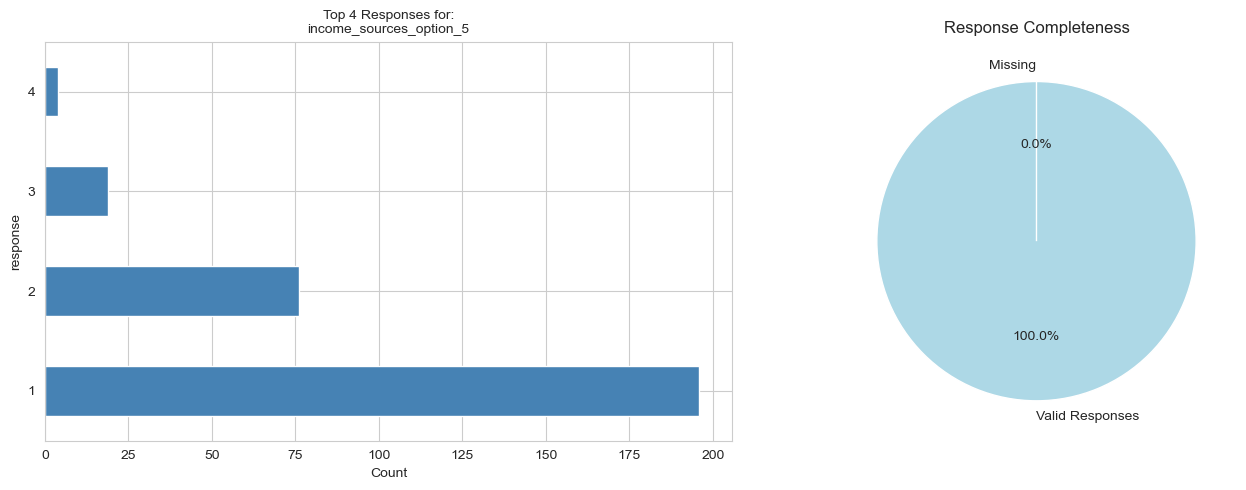


🗺️ Distribution by District:
response   1   2   3  4
district               
Aldhalea  13   3   0  0
Khanfir   76  40  12  2
Radfan    21   2   0  0
Tuban     40   6   0  0
Zingibar  46  25   7  2


QUESTION: added_new_services_after_adra

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
نعم    270
لا      25
Name: count, dtype: int64


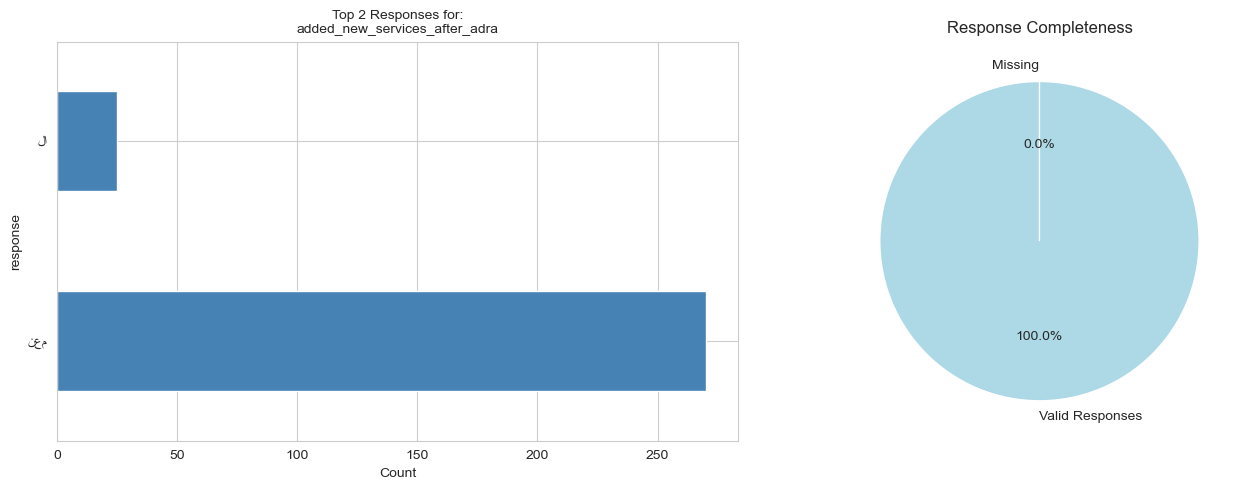


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   7    9
Khanfir   13  117
Radfan     0   23
Tuban      0   46
Zingibar   5   75


QUESTION: market_price_changed_2_years

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 1

📈 Response Distribution:
response
نعم    295
Name: count, dtype: int64


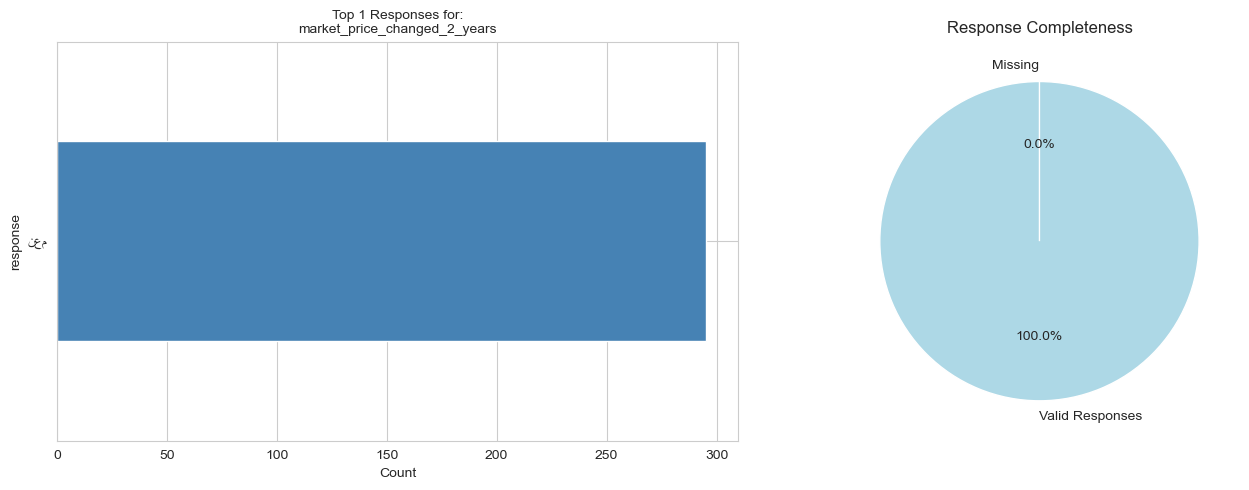


🗺️ Distribution by District:
response  نعم
district     
Aldhalea   16
Khanfir   130
Radfan     23
Tuban      46
Zingibar   80


QUESTION: income_change_after_support

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
في زيادة    190
في نقصان     72
لم يتغير     33
Name: count, dtype: int64


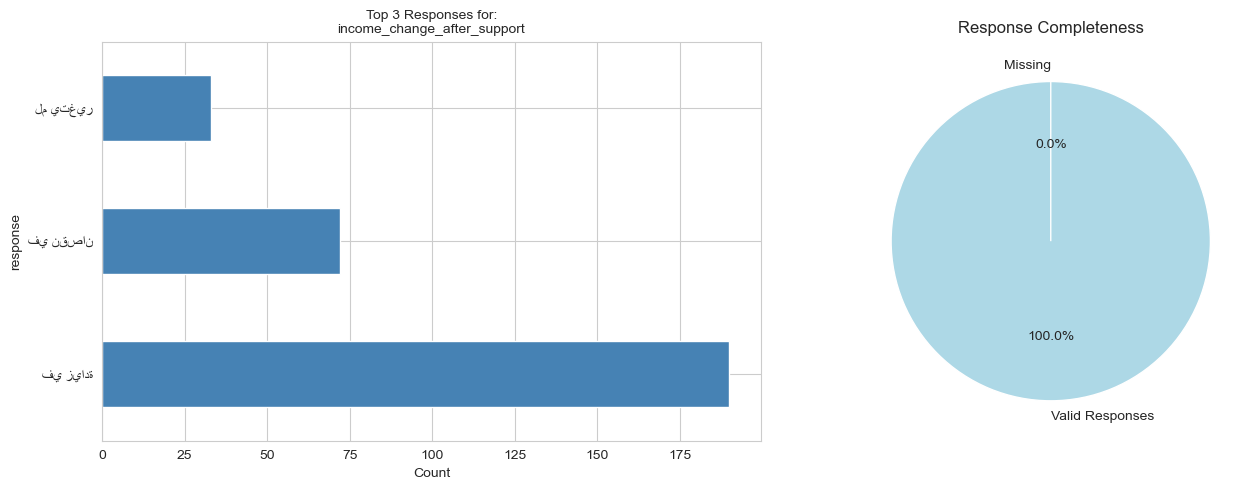


🗺️ Distribution by District:
response  في زيادة  في نقصان  لم يتغير
district                              
Aldhalea         3        11         2
Khanfir         85        28        17
Radfan          19         4         0
Tuban           39         6         1
Zingibar        44        23        13


QUESTION: employees_count_before

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 4

📈 Response Distribution:
response
0.0    26
1.0    14
2.0     5
4.0     1
Name: count, dtype: int64


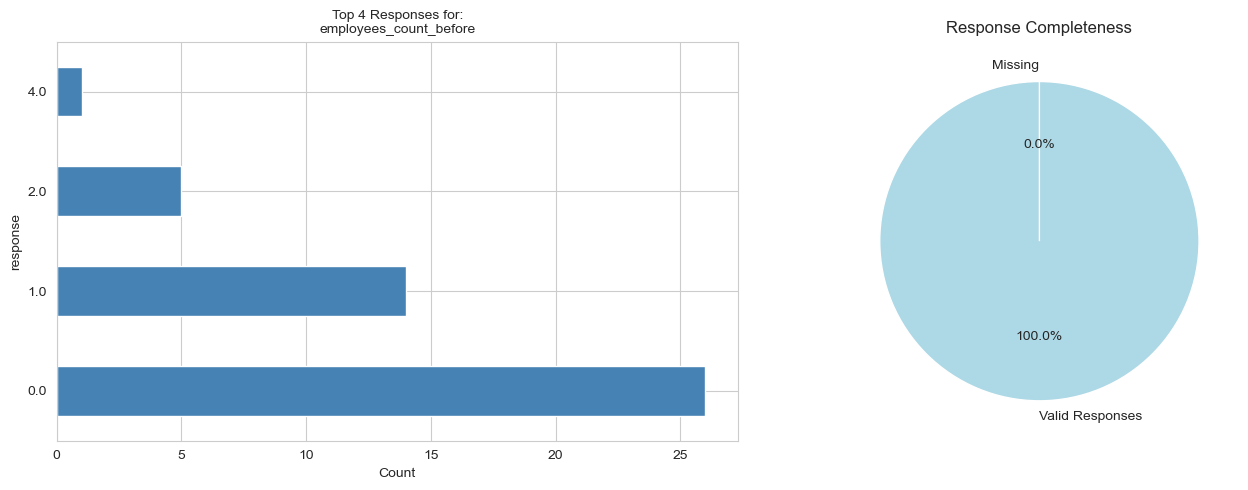


🗺️ Distribution by District:
response  0.0  1.0  2.0  4.0
district                    
Aldhalea    0    1    1    0
Khanfir    18    2    2    1
Radfan      0    3    0    0
Tuban       0    8    1    0
Zingibar    8    0    1    0


QUESTION: work_hours_per_day_before

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 10

📈 Response Distribution:
response
0.0     26
4.0      5
3.0      4
5.0      4
11.0     2
1.0      1
12.0     1
2.0      1
6.0      1
8.0      1
Name: count, dtype: int64


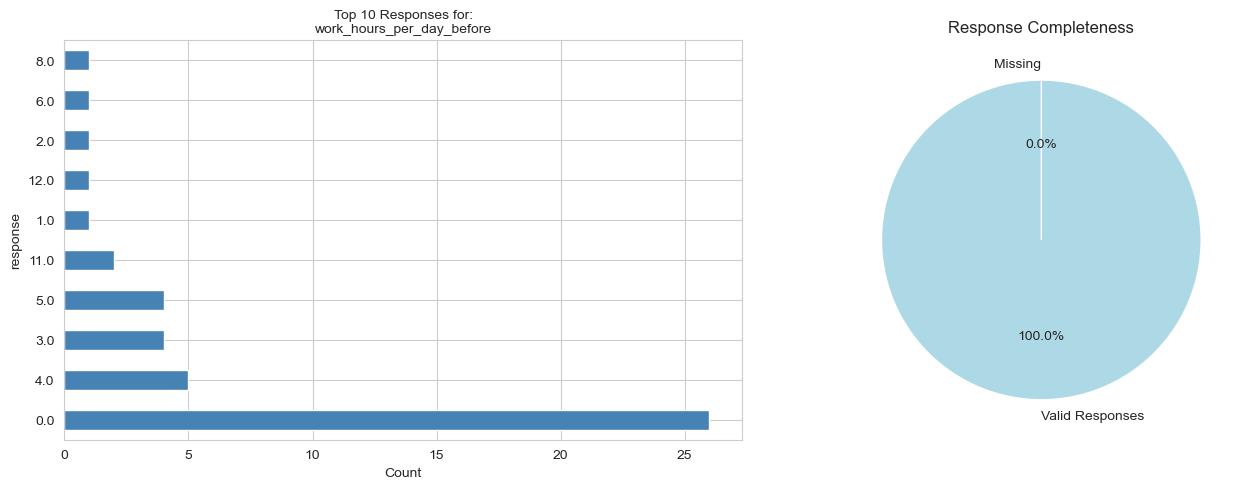


🗺️ Distribution by District:
response  0.0  1.0  11.0  12.0  2.0  3.0  4.0  5.0  6.0  8.0
district                                                    
Aldhalea    0    0     2     0    0    0    0    0    0    0
Khanfir    18    1     0     1    0    1    0    1    0    1
Radfan      0    0     0     0    0    1    1    0    1    0
Tuban       0    0     0     0    1    2    4    2    0    0
Zingibar    8    0     0     0    0    0    0    1    0    0


QUESTION: work_days_per_week_before

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 6

📈 Response Distribution:
response
0.0    26
7.0     6
4.0     5
2.0     4
6.0     3
5.0     2
Name: count, dtype: int64


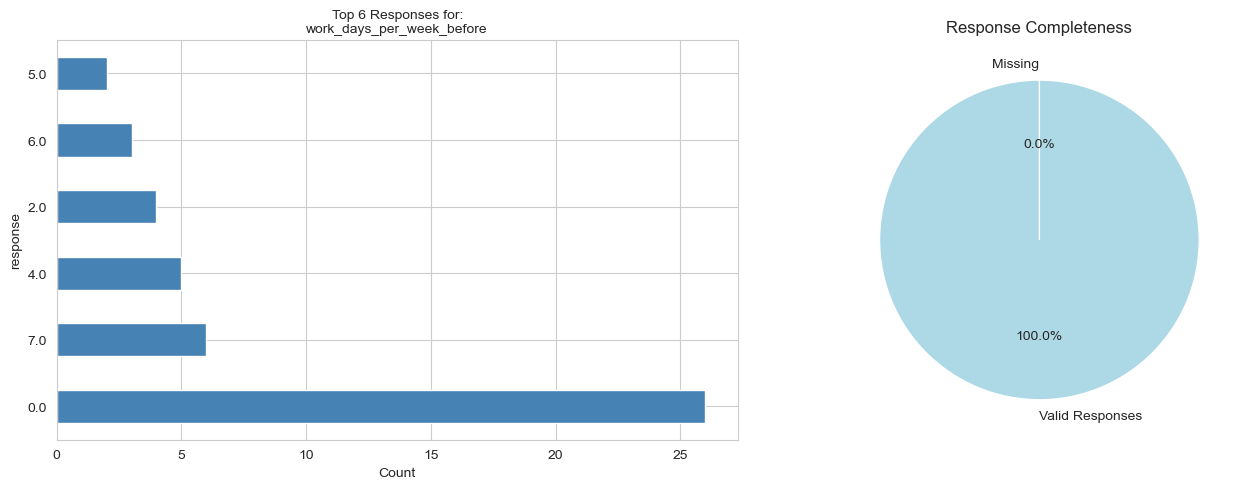


🗺️ Distribution by District:
response  0.0  2.0  4.0  5.0  6.0  7.0
district                              
Aldhalea    0    0    1    0    1    0
Khanfir    18    2    1    0    1    1
Radfan      0    0    1    0    0    2
Tuban       0    2    2    2    0    3
Zingibar    8    0    0    0    1    0


QUESTION: work_months_per_year_before

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 5

📈 Response Distribution:
response
0.0     26
12.0    14
9.0      4
8.0      1
11.0     1
Name: count, dtype: int64


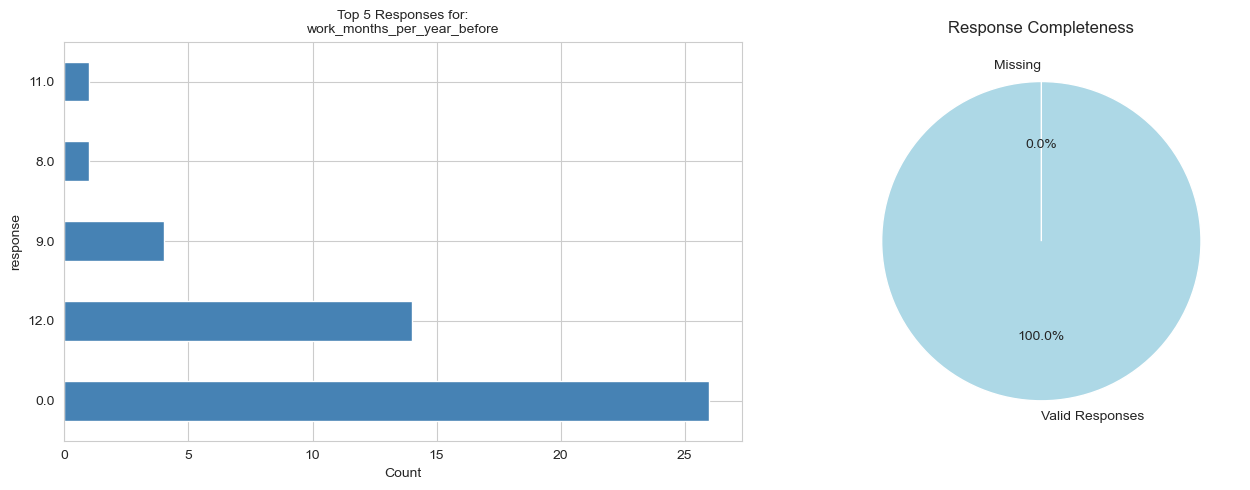


🗺️ Distribution by District:
response  0.0  11.0  12.0  8.0  9.0
district                           
Aldhalea    0     0     1    0    1
Khanfir    18     0     5    0    0
Radfan      0     0     3    0    0
Tuban       0     0     5    1    3
Zingibar    8     1     0    0    0


QUESTION: employees_count_after

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 7

📈 Response Distribution:
response
1.0     16
2.0     14
3.0      6
6.0      4
5.0      3
4.0      2
50.0     1
Name: count, dtype: int64


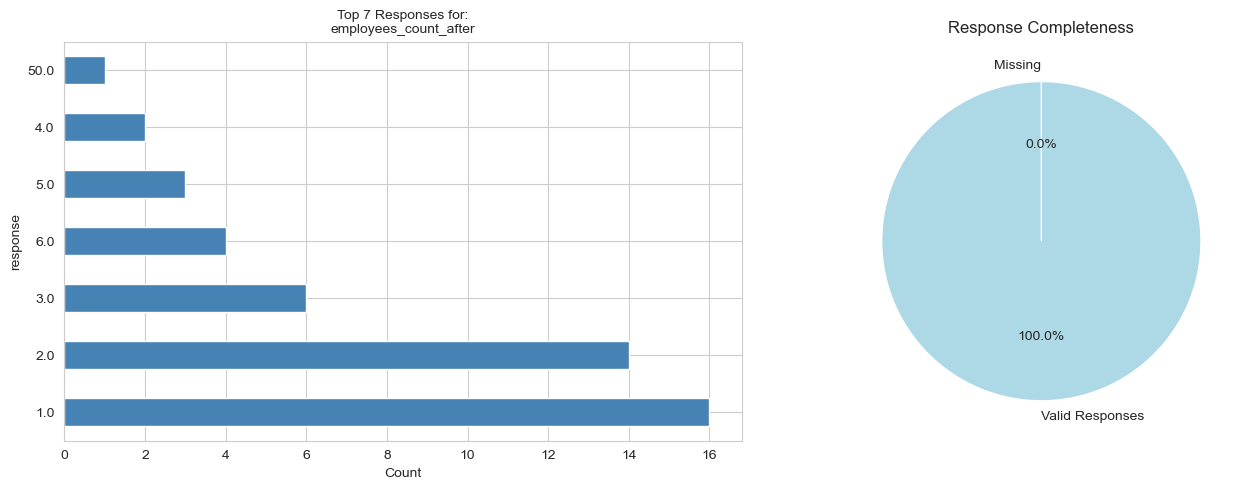


🗺️ Distribution by District:
response  1.0  2.0  3.0  4.0  5.0  50.0  6.0
district                                    
Aldhalea    1    1    0    0    0     0    0
Khanfir     9    5    4    1    2     1    1
Radfan      0    2    0    0    0     0    1
Tuban       2    4    1    0    1     0    1
Zingibar    4    2    1    1    0     0    1


QUESTION: work_hours_per_day_after

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 12

📈 Response Distribution:
response
5.0     10
4.0      8
3.0      7
8.0      5
2.0      4
6.0      3
11.0     3
7.0      2
1.0      1
12.0     1
Name: count, dtype: int64
  ... and 2 more values


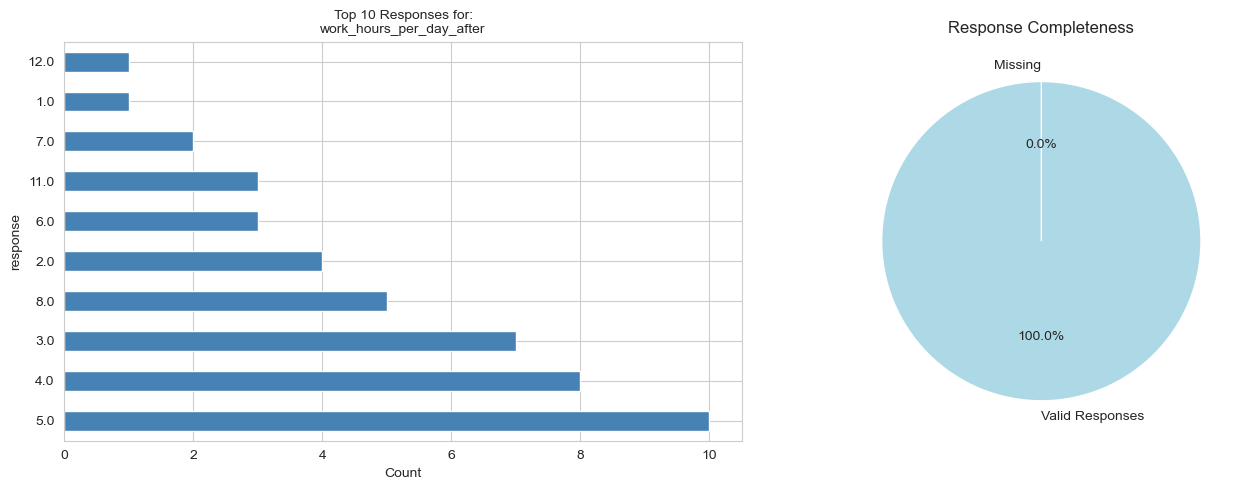


🗺️ Distribution by District:
response  1.0  11.0  12.0  14.0  15.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0
district                                                                
Aldhalea    0     2     0     0     0    0    0    0    0    0    0    0
Khanfir     1     1     0     1     0    2    4    3    5    1    1    4
Radfan      0     0     0     0     1    0    0    0    1    1    0    0
Tuban       0     0     0     0     0    0    1    2    3    1    1    1
Zingibar    0     0     1     0     0    2    2    3    1    0    0    0


QUESTION: work_days_per_week_after

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 6

📈 Response Distribution:
response
7.0    17
3.0     8
4.0     8
6.0     7
5.0     4
2.0     2
Name: count, dtype: int64


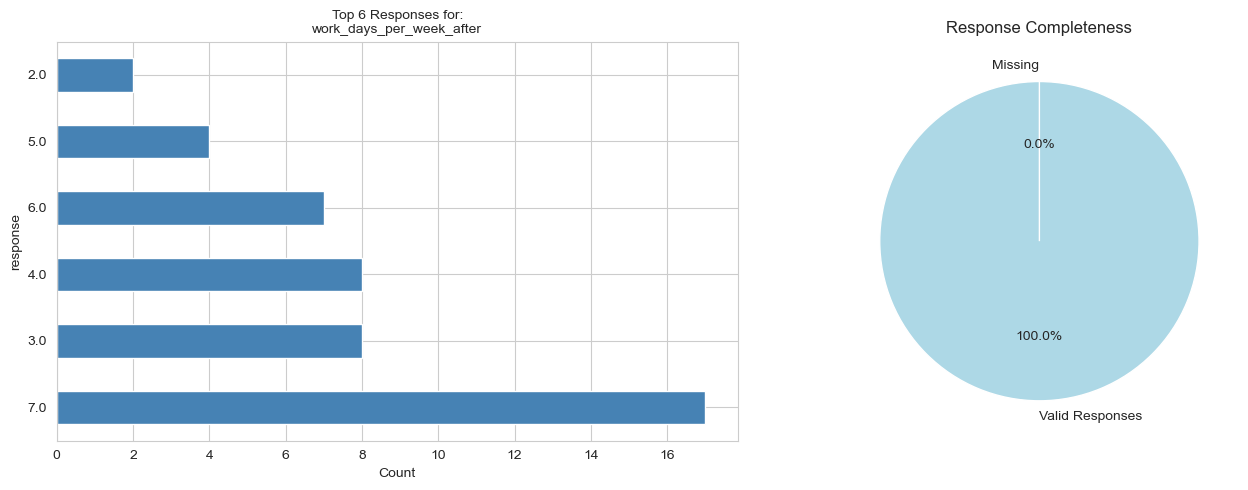


🗺️ Distribution by District:
response  2.0  3.0  4.0  5.0  6.0  7.0
district                              
Aldhalea    0    0    1    0    1    0
Khanfir     1    5    4    3    3    7
Radfan      0    0    0    0    0    3
Tuban       0    0    0    1    1    7
Zingibar    1    3    3    0    2    0


QUESTION: work_months_per_year_after

📊 Basic Statistics:
  Total responses: 46
  Non-null responses: 46
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 8

📈 Response Distribution:
response
12.0    35
7.0      3
6.0      2
3.0      2
4.0      1
2.0      1
11.0     1
9.0      1
Name: count, dtype: int64


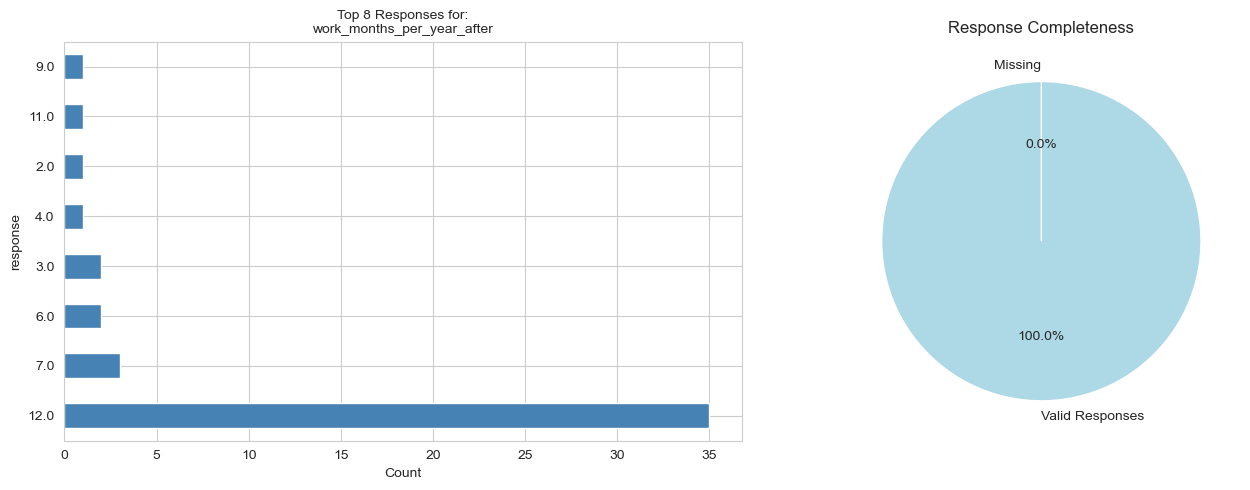


🗺️ Distribution by District:
response  11.0  12.0  2.0  3.0  4.0  6.0  7.0  9.0
district                                          
Aldhalea     0     1    0    0    0    0    0    1
Khanfir      0    18    0    1    1    2    1    0
Radfan       0     3    0    0    0    0    0    0
Tuban        0     9    0    0    0    0    0    0
Zingibar     1     4    1    1    0    0    2    0


QUESTION: family_employees_count

📊 Basic Statistics:
  Total responses: 38
  Non-null responses: 38
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 5

📈 Response Distribution:
response
1.0    22
2.0     9
3.0     4
5.0     2
4.0     1
Name: count, dtype: int64


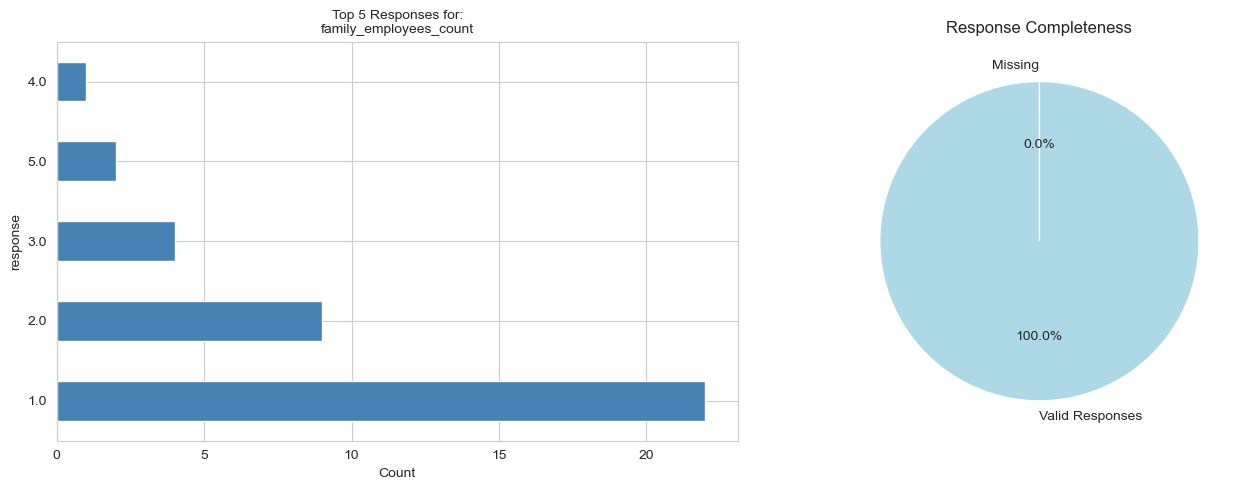


🗺️ Distribution by District:
response  1.0  2.0  3.0  4.0  5.0
district                         
Khanfir    11    6    3    0    1
Radfan      1    0    0    0    1
Tuban       5    2    0    0    0
Zingibar    5    1    1    1    0


QUESTION: family_employees_hours_per_day

📊 Basic Statistics:
  Total responses: 38
  Non-null responses: 38
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 11

📈 Response Distribution:
response
5.0     11
4.0      7
3.0      6
2.0      5
8.0      3
1.0      1
7.0      1
6.0      1
12.0     1
14.0     1
Name: count, dtype: int64
  ... and 1 more values


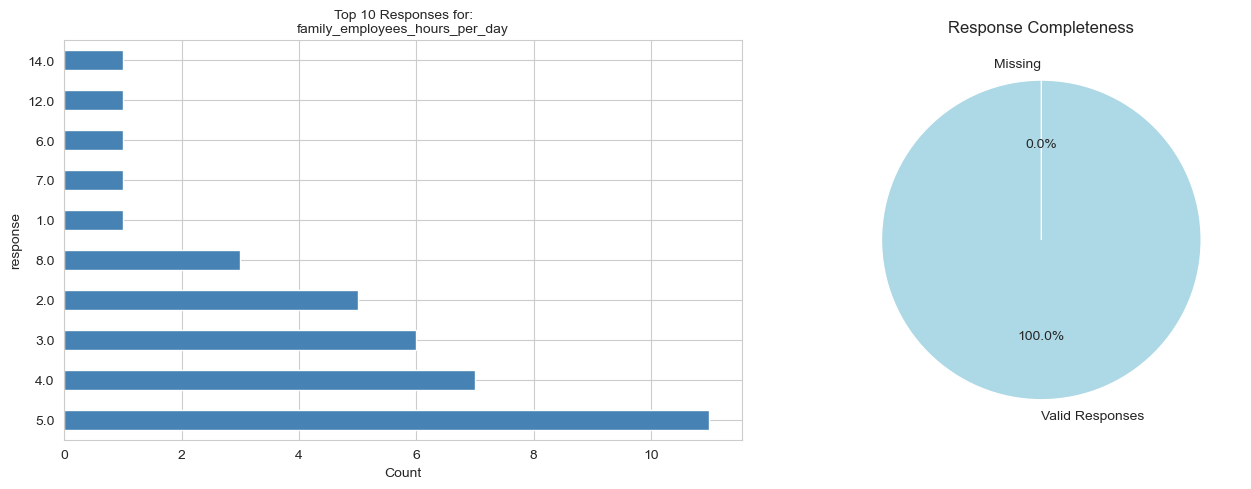


🗺️ Distribution by District:
response  1.0  12.0  14.0  15.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0
district                                                          
Khanfir     1     0     1     0    2    4    3    5    1    1    3
Radfan      0     0     0     1    0    0    0    1    0    0    0
Tuban       0     0     0     0    1    0    2    4    0    0    0
Zingibar    0     1     0     0    2    2    2    1    0    0    0


QUESTION: family_employees_days_per_week

📊 Basic Statistics:
  Total responses: 38
  Non-null responses: 38
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 6

📈 Response Distribution:
response
7.0    12
3.0     9
4.0     7
5.0     4
6.0     4
2.0     2
Name: count, dtype: int64


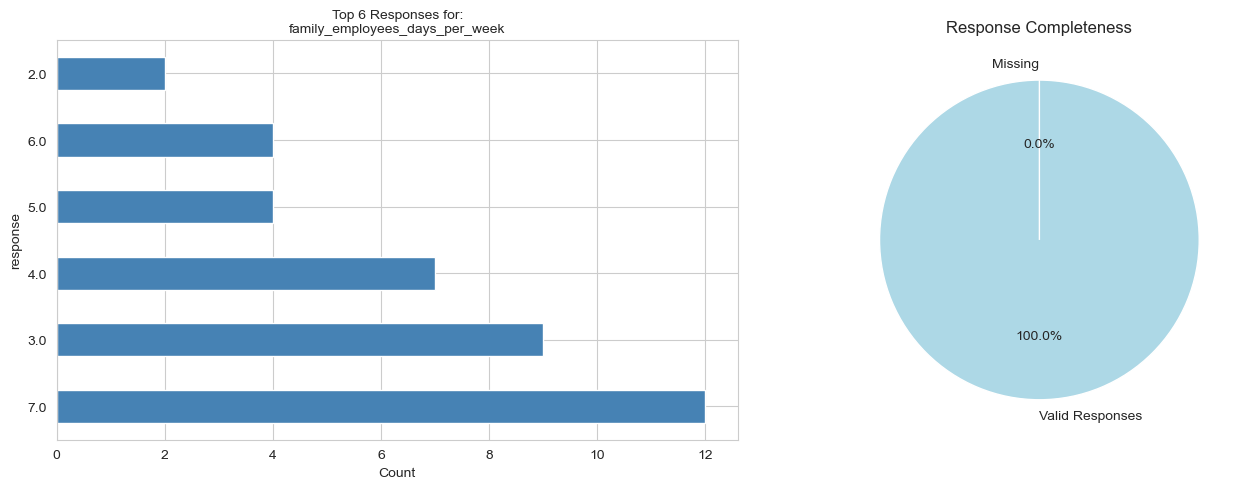


🗺️ Distribution by District:
response  2.0  3.0  4.0  5.0  6.0  7.0
district                              
Khanfir     1    5    4    2    2    7
Radfan      0    0    0    0    0    2
Tuban       0    1    0    2    1    3
Zingibar    1    3    3    0    1    0


QUESTION: family_employees_months_per_year

📊 Basic Statistics:
  Total responses: 38
  Non-null responses: 38
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 8

📈 Response Distribution:
response
12.0    27
7.0      3
6.0      2
3.0      2
4.0      1
9.0      1
2.0      1
11.0     1
Name: count, dtype: int64


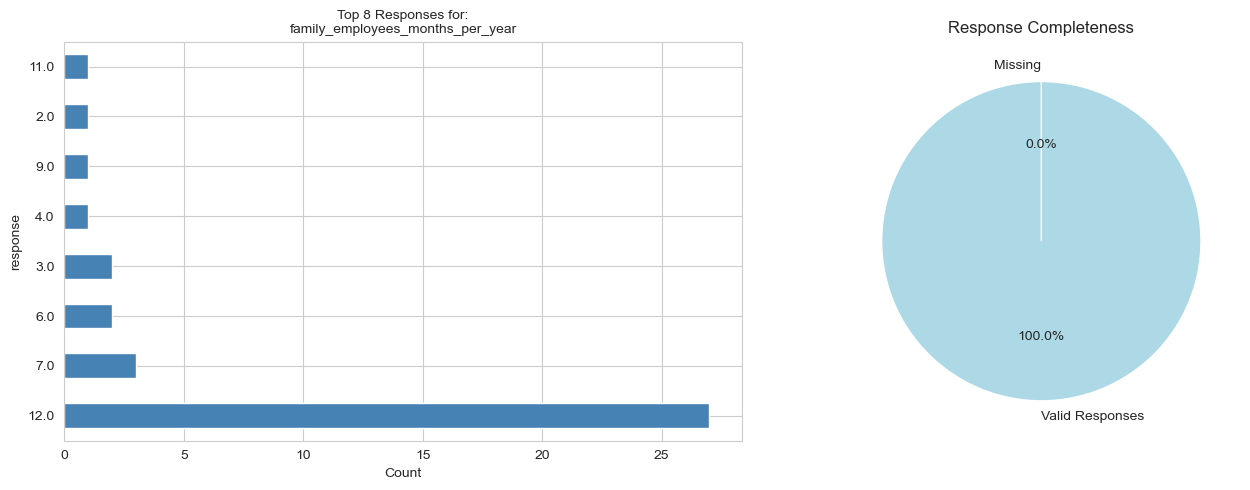


🗺️ Distribution by District:
response  11.0  12.0  2.0  3.0  4.0  6.0  7.0  9.0
district                                          
Khanfir      0    16    0    1    1    2    1    0
Radfan       0     2    0    0    0    0    0    0
Tuban        0     6    0    0    0    0    0    1
Zingibar     1     3    1    1    0    0    2    0


QUESTION: outside_employees_count

📊 Basic Statistics:
  Total responses: 17
  Non-null responses: 17
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 7

📈 Response Distribution:
response
2.0     5
1.0     5
3.0     2
5.0     2
0.0     1
8.0     1
50.0    1
Name: count, dtype: int64


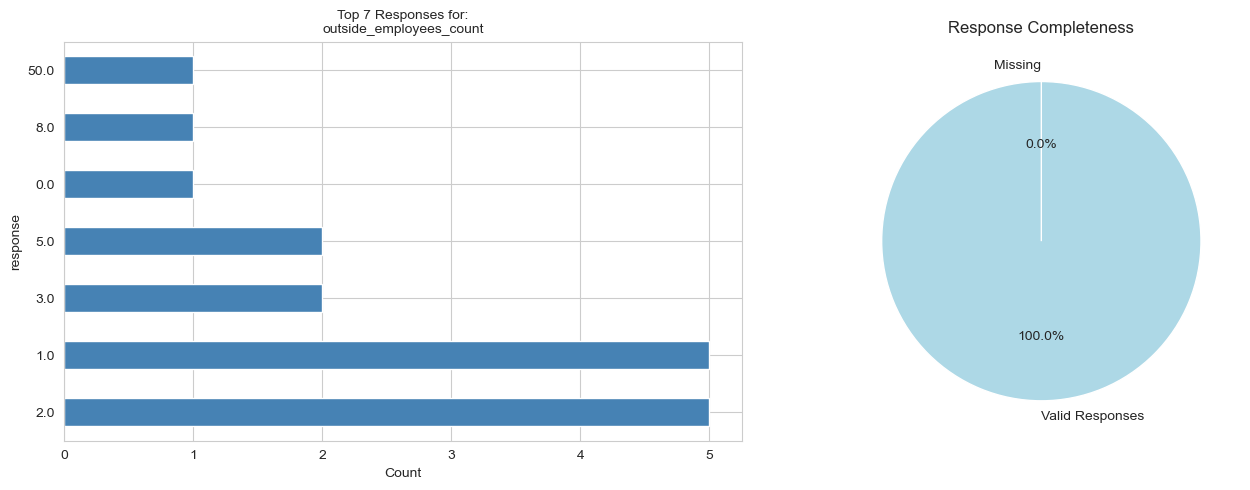


🗺️ Distribution by District:
response  0.0  1.0  2.0  3.0  5.0  50.0  8.0
district                                    
Aldhalea    0    1    1    0    0     0    0
Khanfir     1    2    3    1    0     1    1
Radfan      0    0    1    0    0     0    0
Tuban       0    1    0    0    2     0    0
Zingibar    0    1    0    1    0     0    0


QUESTION: outside_employees_hours_per_day

📊 Basic Statistics:
  Total responses: 17
  Non-null responses: 17
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 9

📈 Response Distribution:
response
4.0     3
3.0     3
11.0    3
2.0     2
8.0     2
0.0     1
7.0     1
5.0     1
6.0     1
Name: count, dtype: int64


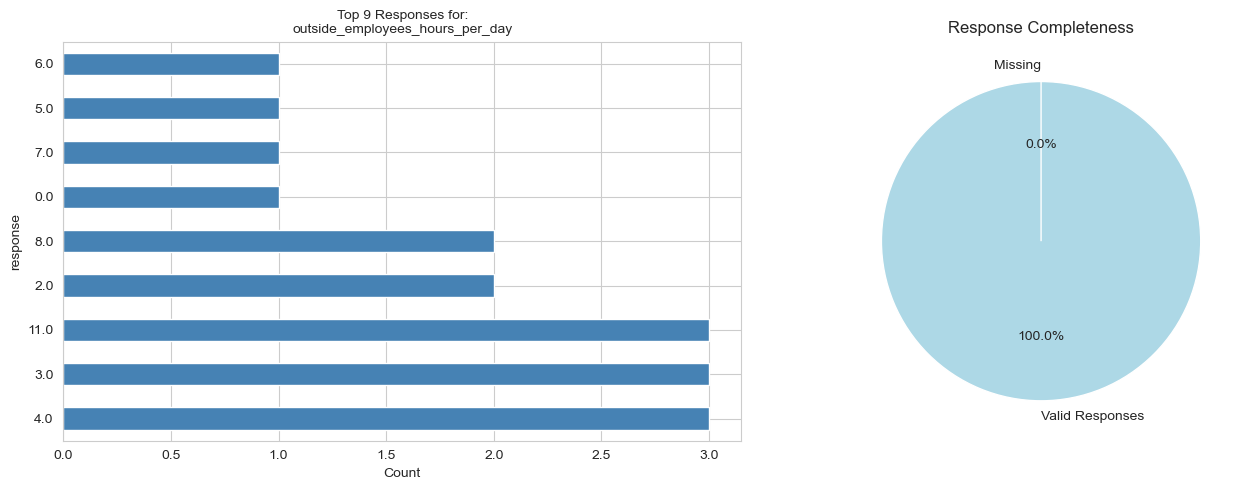


🗺️ Distribution by District:
response  0.0  11.0  2.0  3.0  4.0  5.0  6.0  7.0  8.0
district                                              
Aldhalea    0     2    0    0    0    0    0    0    0
Khanfir     1     1    2    1    2    0    0    0    2
Radfan      0     0    0    0    0    0    1    0    0
Tuban       0     0    0    1    0    1    0    1    0
Zingibar    0     0    0    1    1    0    0    0    0


QUESTION: outside_employees_days_per_week

📊 Basic Statistics:
  Total responses: 17
  Non-null responses: 17
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 7

📈 Response Distribution:
response
6.0    4
5.0    4
4.0    3
7.0    2
3.0    2
2.0    1
0.0    1
Name: count, dtype: int64


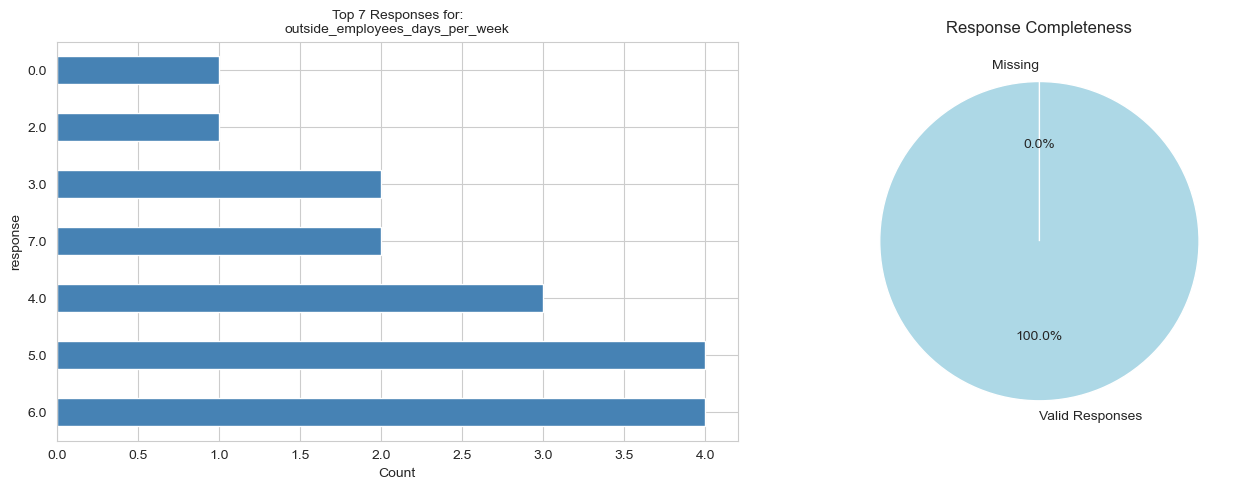


🗺️ Distribution by District:
response  0.0  2.0  3.0  4.0  5.0  6.0  7.0
district                                   
Aldhalea    0    0    0    1    0    1    0
Khanfir     1    1    2    1    2    2    0
Radfan      0    0    0    0    0    0    1
Tuban       0    0    0    0    2    0    1
Zingibar    0    0    0    1    0    1    0


QUESTION: outside_employees_months_per_year

📊 Basic Statistics:
  Total responses: 17
  Non-null responses: 17
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 6

📈 Response Distribution:
response
12.0    10
6.0      2
7.0      2
0.0      1
4.0      1
9.0      1
Name: count, dtype: int64


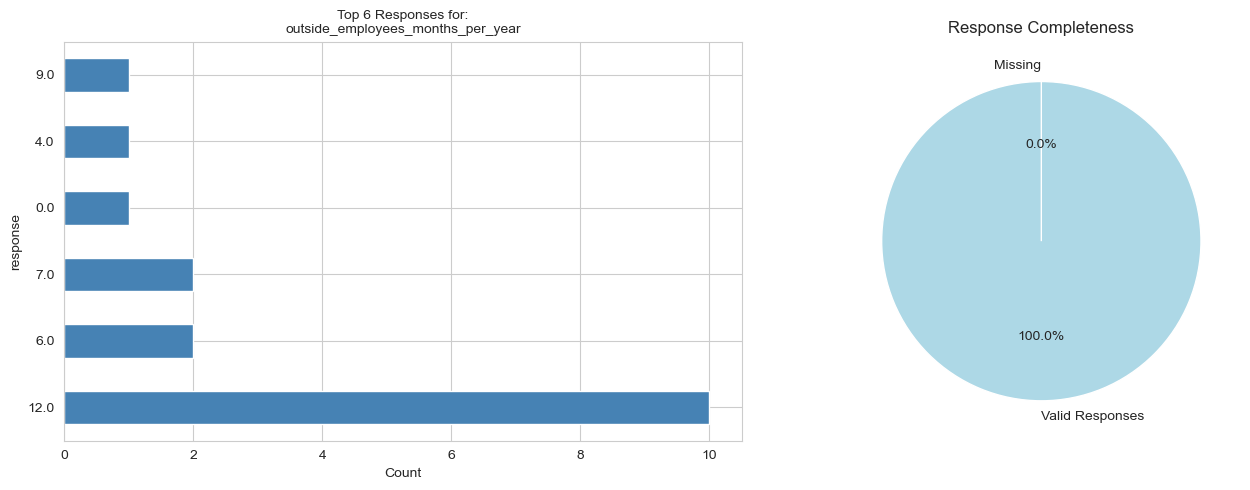


🗺️ Distribution by District:
response  0.0  12.0  4.0  6.0  7.0  9.0
district                               
Aldhalea    0     1    0    0    0    1
Khanfir     1     4    1    2    1    0
Radfan      0     1    0    0    0    0
Tuban       0     3    0    0    0    0
Zingibar    0     1    0    0    1    0


QUESTION: independent_workspace_available

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
نعم    190
لا     105
Name: count, dtype: int64


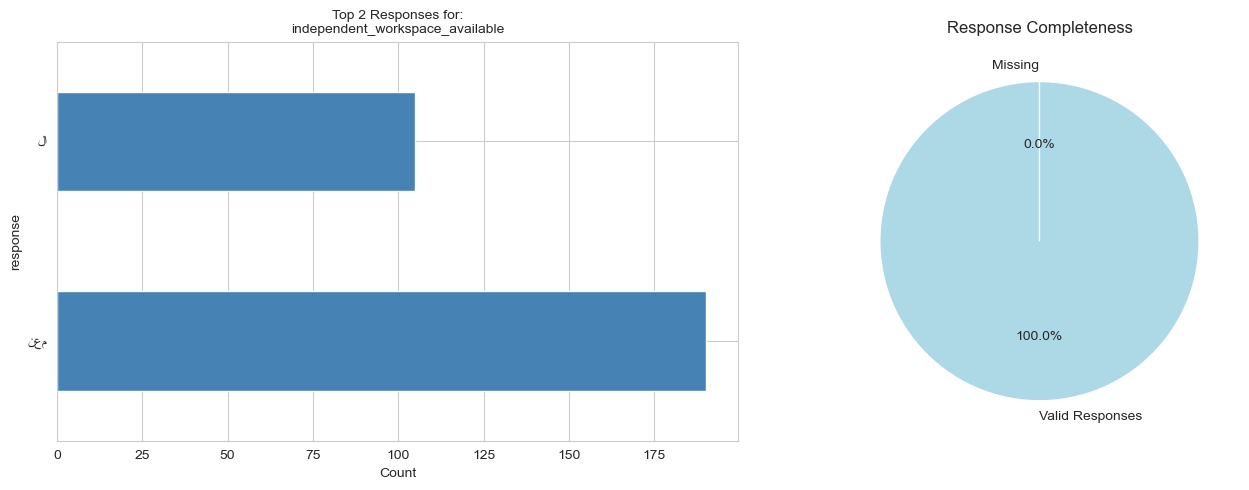


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   3   13
Khanfir   55   75
Radfan     4   19
Tuban     14   32
Zingibar  29   51


QUESTION: workspace_description

📊 Basic Statistics:
  Total responses: 190
  Non-null responses: 190
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 6

📈 Response Distribution:
response
غرفة           123
محل             32
كشك             28
مستودع           4
مطبخ/ بوفية      2
مركز             1
Name: count, dtype: int64


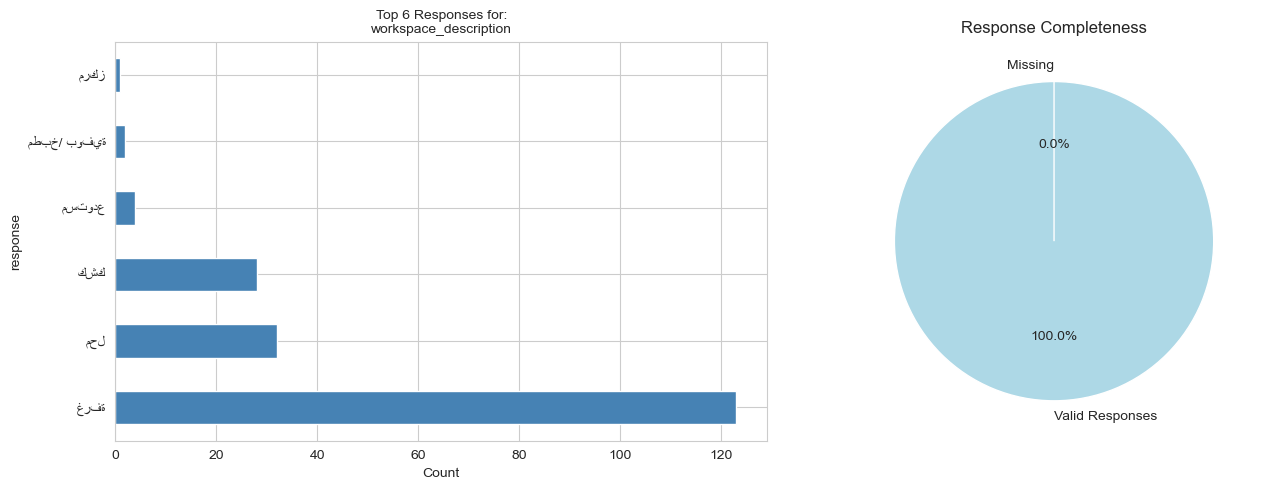


🗺️ Distribution by District:
response  غرفة  كشك  محل  مركز  مستودع  مطبخ/ بوفية
district                                           
Aldhalea     8    3    1     0       1            0
Khanfir     51   12   10     1       1            0
Radfan       5    3    7     0       2            2
Tuban       31    0    1     0       0            0
Zingibar    28   10   13     0       0            0


QUESTION: product_sales_method

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
كلاهما    207
نقدا       46
دين        42
Name: count, dtype: int64


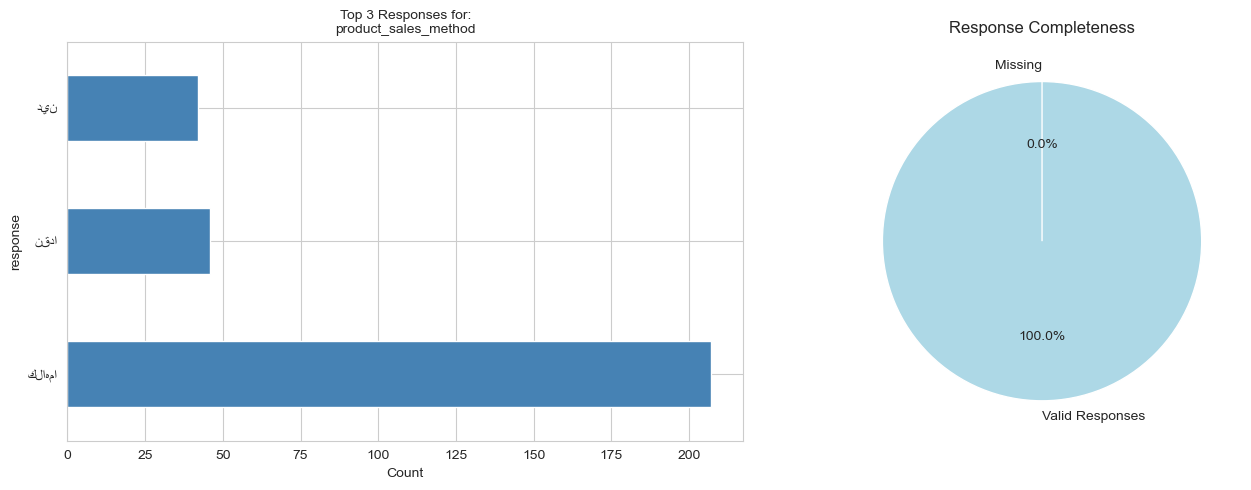


🗺️ Distribution by District:
response  دين  كلاهما  نقدا
district                   
Aldhalea    0      15     1
Khanfir    20      86    24
Radfan      0      19     4
Tuban       7      35     4
Zingibar   15      52    13


QUESTION: trader_integration_with_adra_businesses

📊 Basic Statistics:
  Total responses: 210
  Non-null responses: 210
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 1

📈 Response Distribution:
response
OK    210
Name: count, dtype: int64


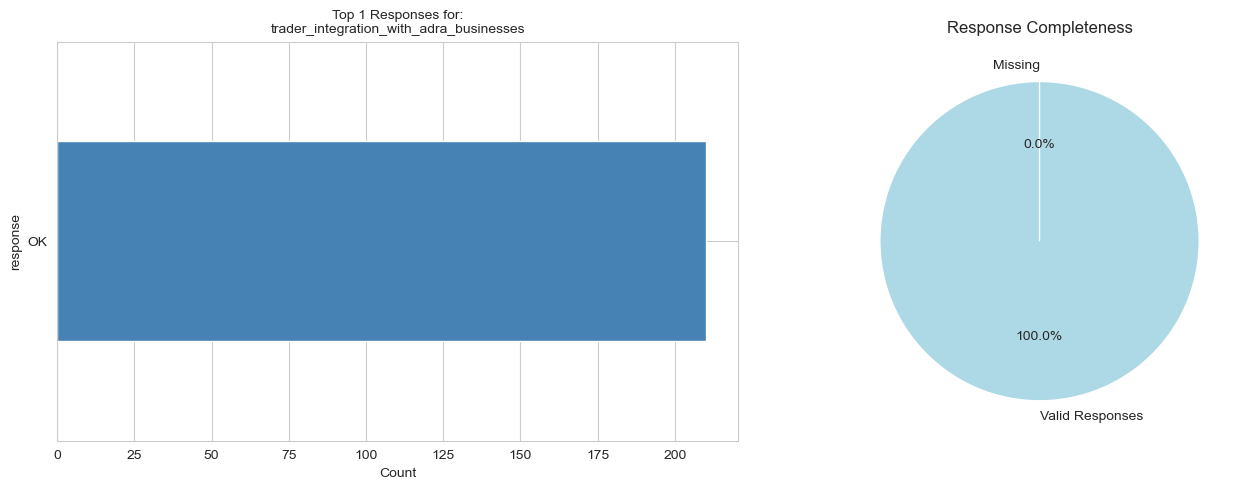


🗺️ Distribution by District:
response   OK
district     
Aldhalea   16
Khanfir   110
Radfan      7
Tuban      14
Zingibar   63


QUESTION: purchased_from_erms_suppliers

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
لا     197
نعم     98
Name: count, dtype: int64


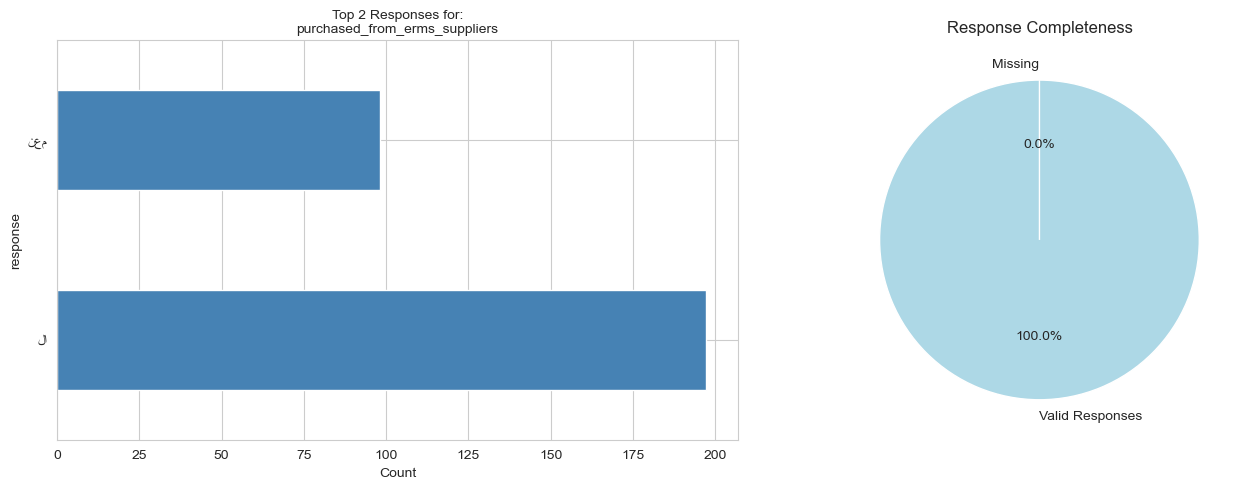


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   8    8
Khanfir   77   53
Radfan    21    2
Tuban     40    6
Zingibar  51   29


QUESTION: trader_relationship_assessment

📊 Basic Statistics:
  Total responses: 98
  Non-null responses: 98
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
جيد جدا    88
جيد         9
عادي        1
Name: count, dtype: int64


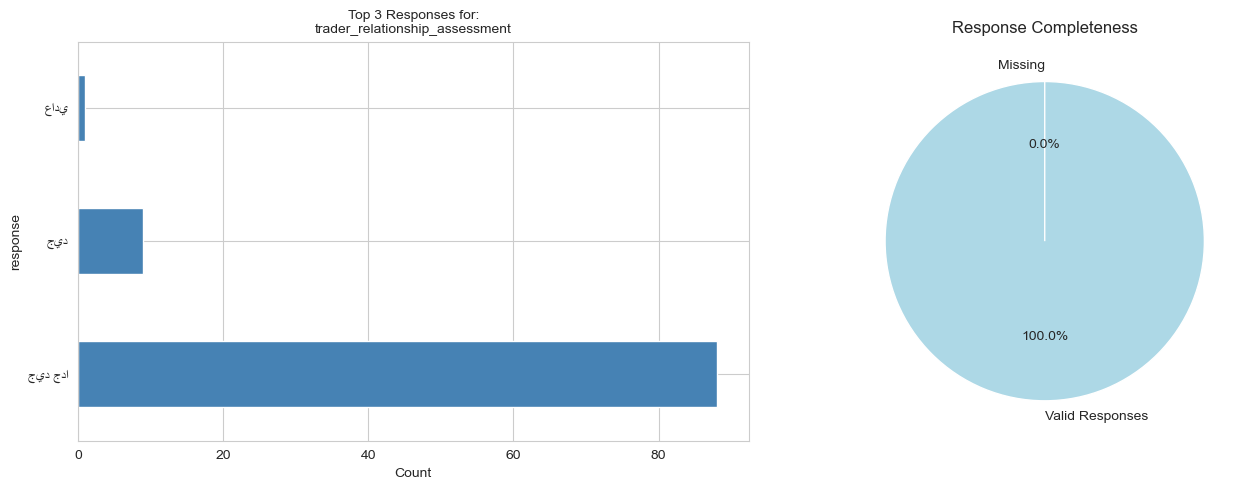


🗺️ Distribution by District:
response  جيد  جيد جدا  عادي
district                    
Aldhalea    3        5     0
Khanfir     4       49     0
Radfan      0        2     0
Tuban       1        5     0
Zingibar    1       27     1


QUESTION: traders_purchased_from_us

📊 Basic Statistics:
  Total responses: 98
  Non-null responses: 98
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
نعم    85
لا     13
Name: count, dtype: int64


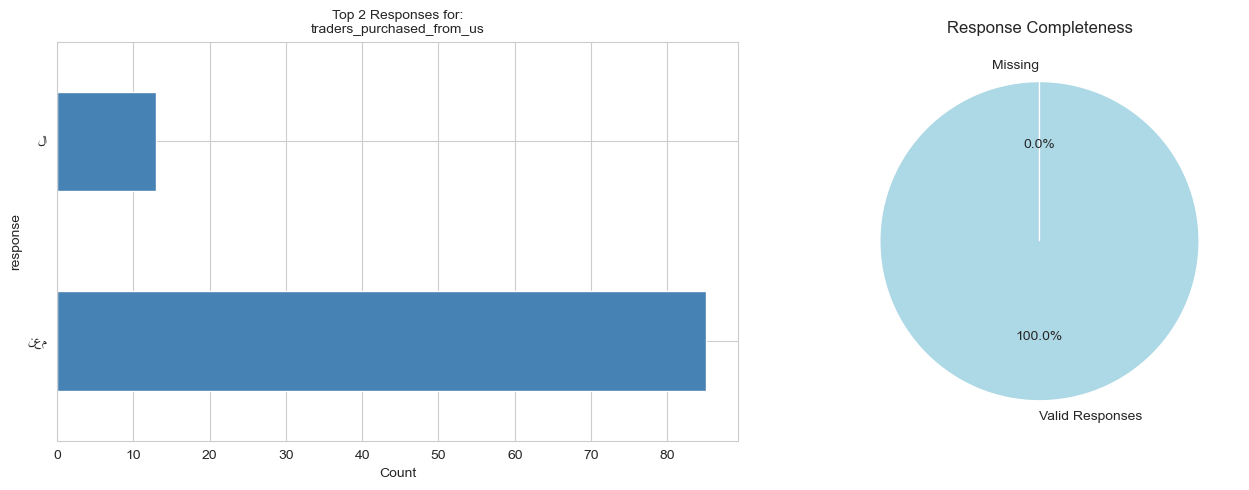


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   1    7
Khanfir    2   51
Radfan     1    1
Tuban      0    6
Zingibar   9   20


QUESTION: competitors_exist_in_area

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
نعم    254
لا      41
Name: count, dtype: int64


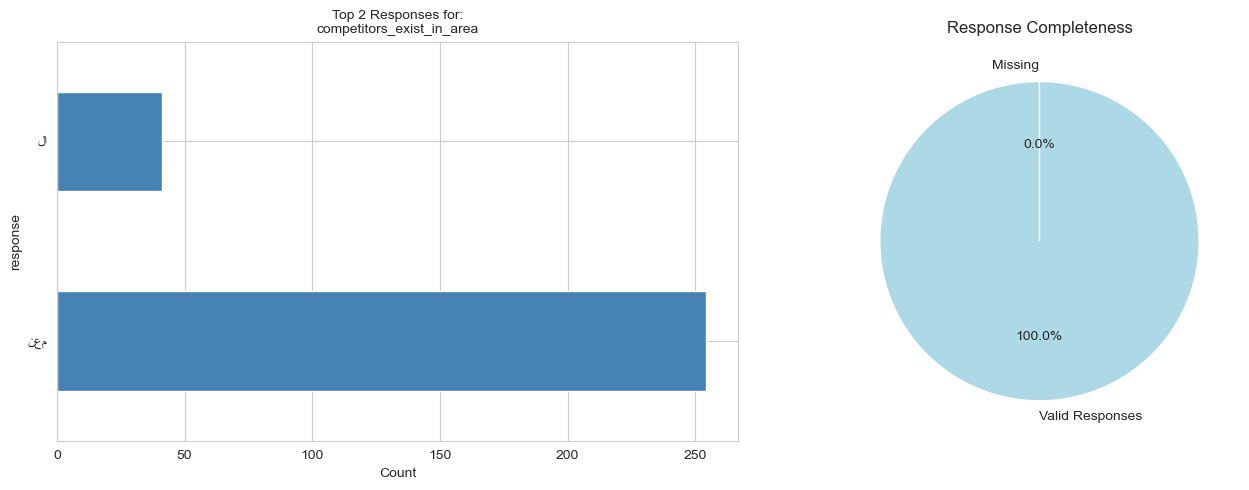


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   3   13
Khanfir   20  110
Radfan     1   22
Tuban      4   42
Zingibar  13   67


QUESTION: competitors_income_impact

📊 Basic Statistics:
  Total responses: 254
  Non-null responses: 254
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
زيادة    149
نقصان    105
Name: count, dtype: int64


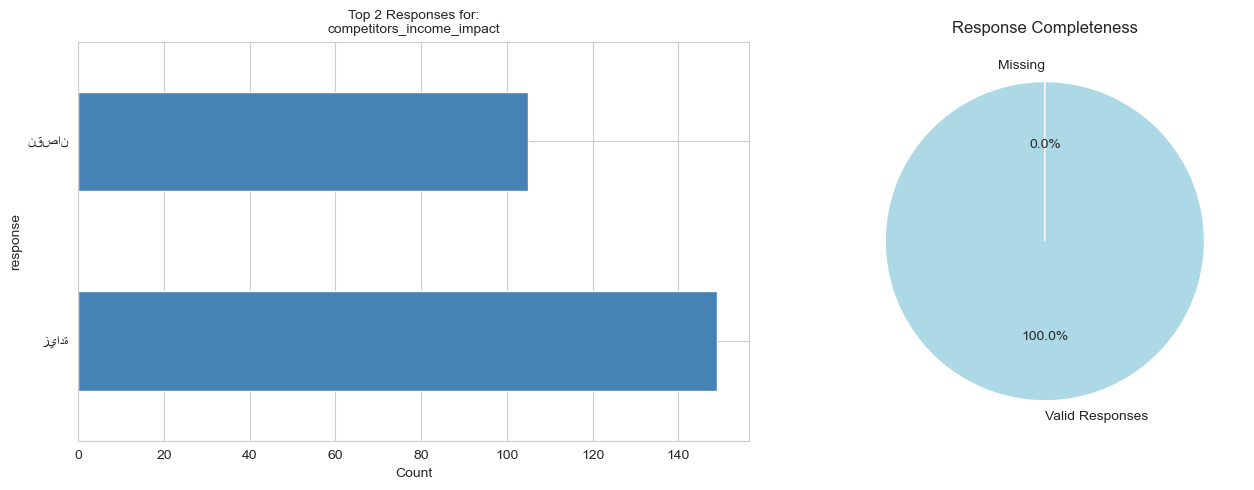


🗺️ Distribution by District:
response  زيادة  نقصان
district              
Aldhalea      5      8
Khanfir      54     56
Radfan       21      1
Tuban        34      8
Zingibar     35     32


QUESTION: product_sales_method_2

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
تجزئة              201
كلاهما              91
جملة - عبر تاجر      3
Name: count, dtype: int64


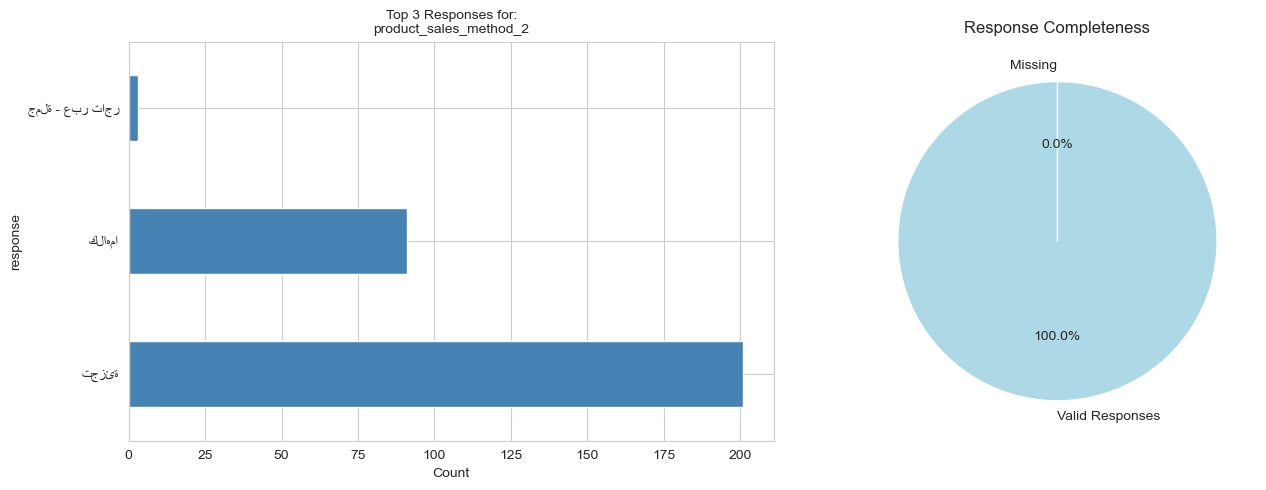


🗺️ Distribution by District:
response  تجزئة  جملة - عبر تاجر  كلاهما
district                                
Aldhalea      8                0       8
Khanfir      86                2      42
Radfan       15                0       8
Tuban        26                0      20
Zingibar     66                1      13


QUESTION: business_client_companies

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 76

📈 Response Distribution:
response
لا يوجد فقط افراد    205
محلات ملابس            4
مقاولين                4
محلات الملابس          3
الأعراس\nالحفلات       3
الدلالات               3
التجار                 2
تجار ونساء             2
دلالات                 2
تاجر سمك               1
Name: count, dtype: int64
  ... and 66 more values


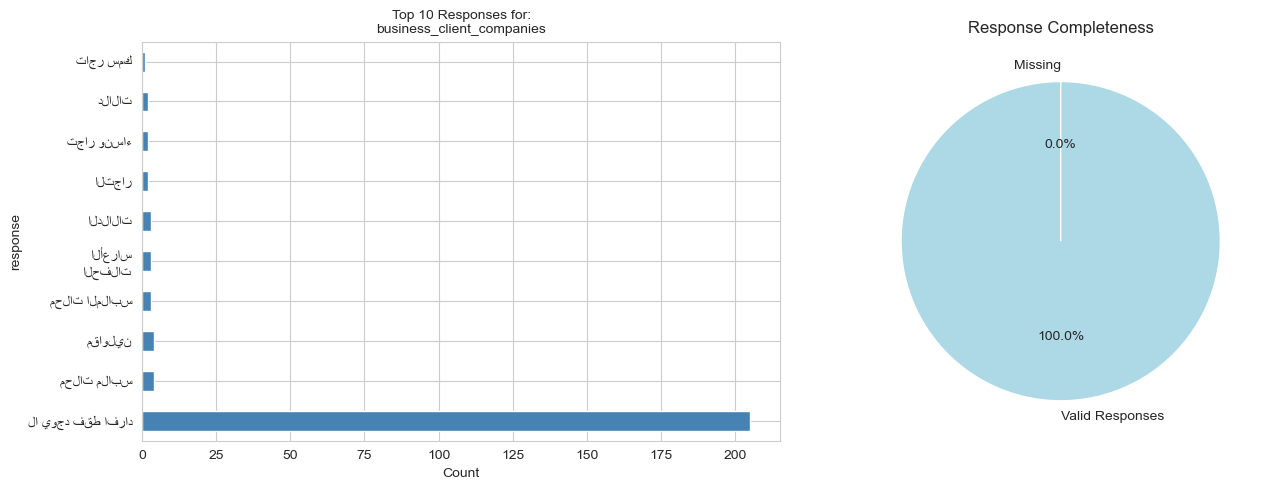


🗺️ Distribution by District:
response   مقاولين  أصحاب مزارع النحل   إدارة الكهرباء وصندوق النظافه  \
district                                                                
Aldhalea         0                   0                              0   
Khanfir          0                   1                              0   
Radfan           1                   0                              1   
Tuban            0                   0                              0   
Zingibar         0                   0                              0   

response  اصحاب الدرجات النارية  اصحاب المنازل (المناسبات والافراح)  \
district                                                              
Aldhalea                      1                                   1   
Khanfir                       0                                   0   
Radfan                        0                                   0   
Tuban                         0                                   0   
Zingibar                      0 

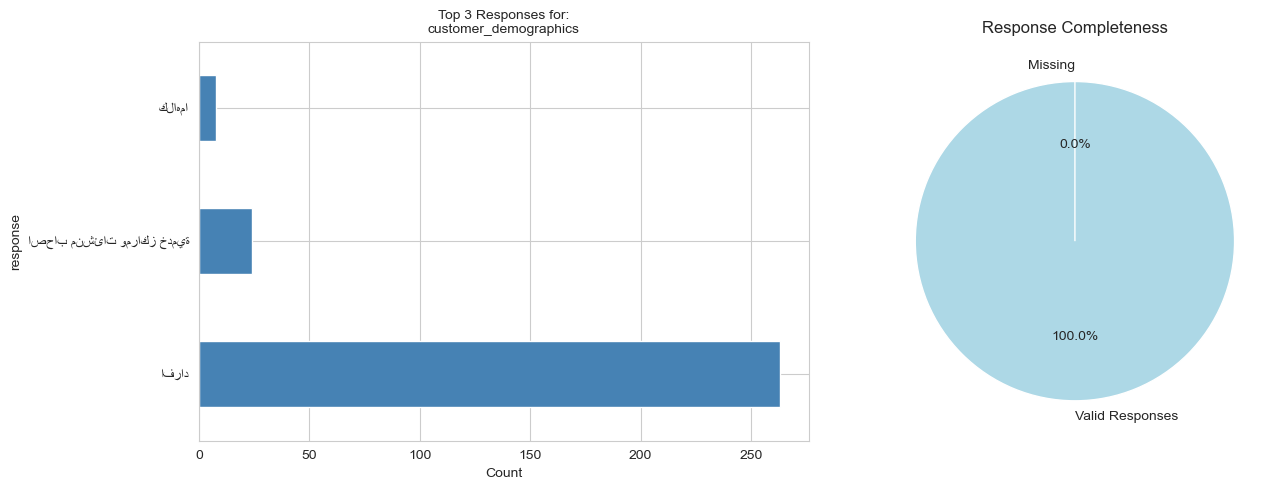


🗺️ Distribution by District:
response  اصحاب منشئات ومراكز خدمية  افراد  كلاهما
district                                          
Aldhalea                          0     16       0
Khanfir                          15    110       5
Radfan                            7     14       2
Tuban                             1     44       1
Zingibar                          1     79       0


QUESTION: customer_purchasing_ability

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
نعم    281
لا      14
Name: count, dtype: int64


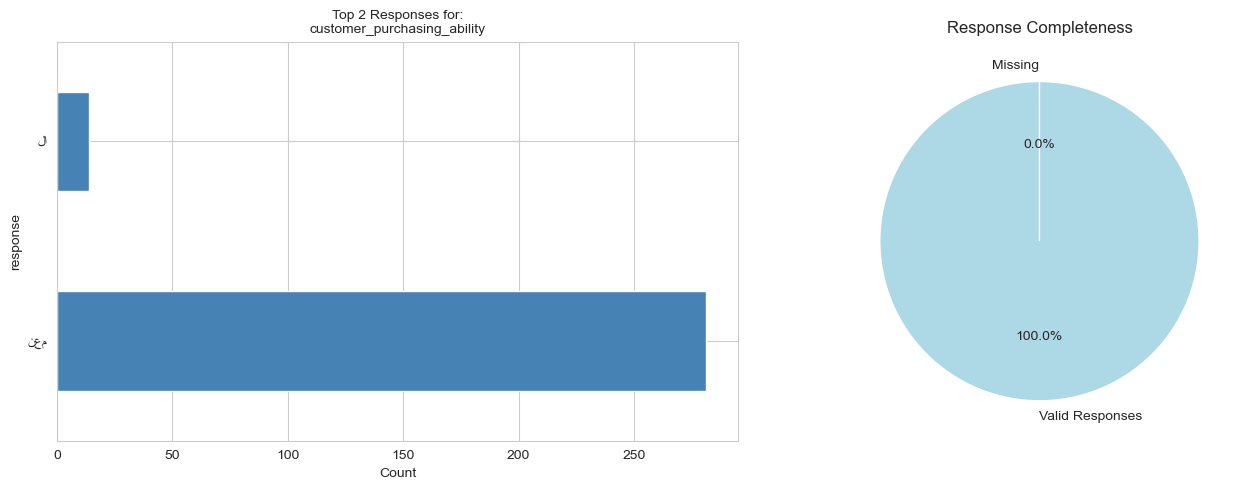


🗺️ Distribution by District:
response  لا  نعم
district         
Aldhalea   0   16
Khanfir    7  123
Radfan     2   21
Tuban      3   43
Zingibar   2   78


QUESTION: market_prices_changed_recent

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
زادت        293
لم تتغير      2
Name: count, dtype: int64


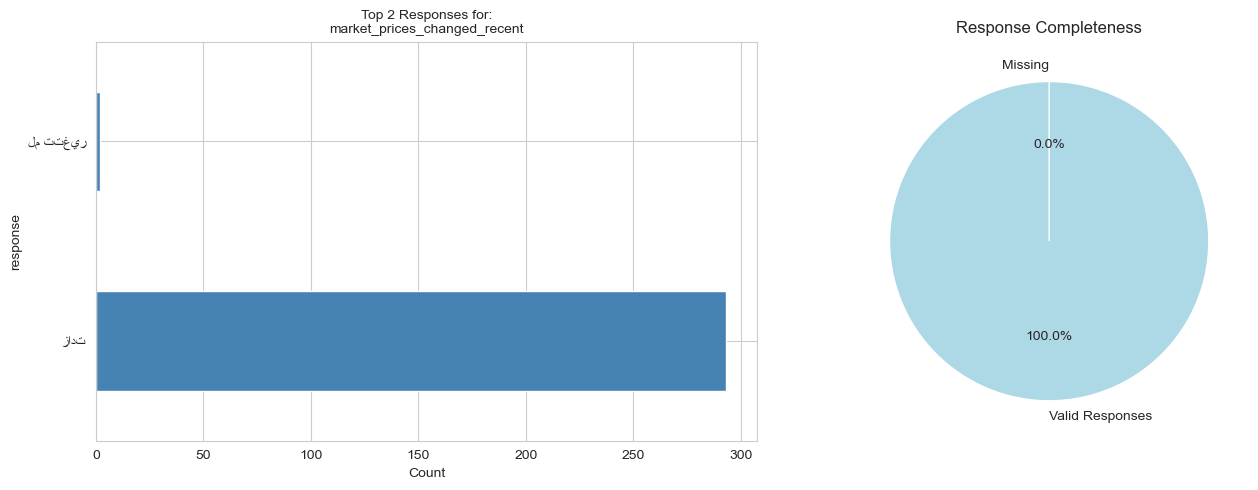


🗺️ Distribution by District:
response  زادت  لم تتغير
district                
Aldhalea    16         0
Khanfir    129         1
Radfan      23         0
Tuban       46         0
Zingibar    79         1


QUESTION: price_change_percentage

📊 Basic Statistics:
  Total responses: 293
  Non-null responses: 293
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 4

📈 Response Distribution:
response
1.0     178
0.5      86
0.25     28
0.1       1
Name: count, dtype: int64


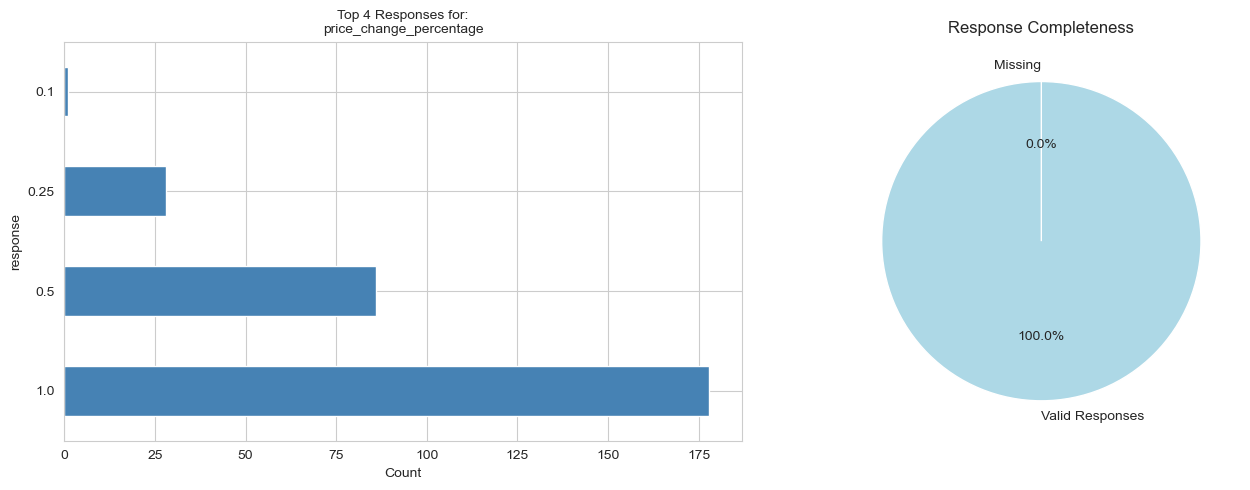


🗺️ Distribution by District:
response  0.1  0.25  0.5  1.0
district                     
Aldhalea    0     0    3   13
Khanfir     0     6   35   88
Radfan      0     6   10    7
Tuban       0    14   20   12
Zingibar    1     2   18   58


QUESTION: customer_transaction_frequency

📊 Basic Statistics:
  Total responses: 295
  Non-null responses: 295
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 4

📈 Response Distribution:
response
بشكل شهري    128
بشكل دائم     92
بشكل يومي     56
نادرا         19
Name: count, dtype: int64


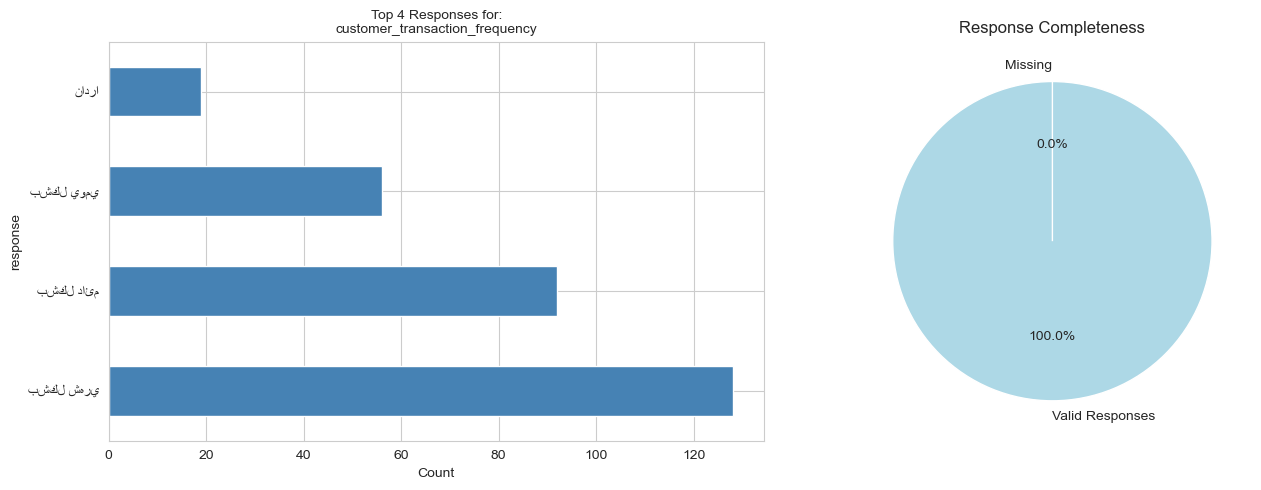


🗺️ Distribution by District:
response  بشكل دائم  بشكل شهري  بشكل يومي  نادرا
district                                        
Aldhalea          1         11          4      0
Khanfir          39         60         22      9
Radfan            6          7         10      0
Tuban            16         25          4      1
Zingibar         30         25         16      9




In [107]:
import analysis

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Analyze all Single Response questions
print("\n" + "#" * 80)
print("# SINGLE RESPONSE QUESTIONS - EDA")
print("#" * 80 + "\n")

for question in erms_sr_questions:
    analyze_question(erms_melted_sr, question, question_type='SR')


# # Analyze all Multiple Response questions
# print("\n" + "#" * 80)
# print("# MULTIPLE RESPONSE QUESTIONS - EDA")
# print("#" * 80 + "\n")

# for question in erms_mr_questions:
#     analyze_question(erms_melted_mr, question, question_type='MR')


################################################################################
# SINGLE RESPONSE QUESTIONS - EDA
################################################################################

QUESTION: product_service_difference

📊 Basic Statistics:
  Total responses: 330
  Non-null responses: 330
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
Yes        271
No Idea     32
No          27
Name: count, dtype: int64


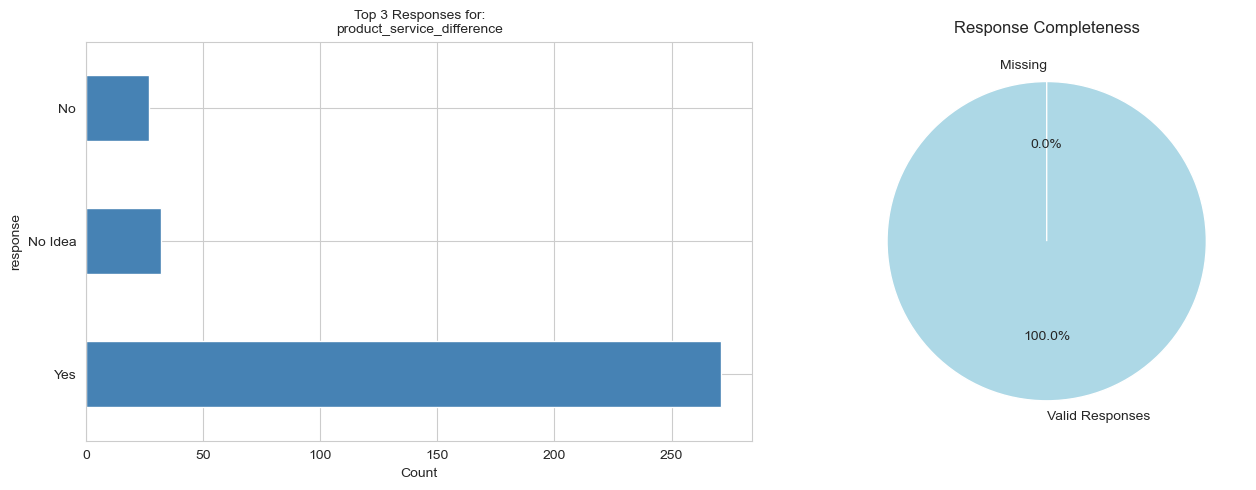


🗺️ Distribution by District:
response    No  No Idea  Yes
district                    
Aldhalea     1        1   24
Almadharba   0        3    0
Khanfir      6       10   60
Radfan       6        8   43
Sarar        2        0    9
Tuban        4        3   54
Zingibar     8        7   81


QUESTION: dealt_with_business_owner

📊 Basic Statistics:
  Total responses: 330
  Non-null responses: 330
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 1

📈 Response Distribution:
response
Yes    330
Name: count, dtype: int64


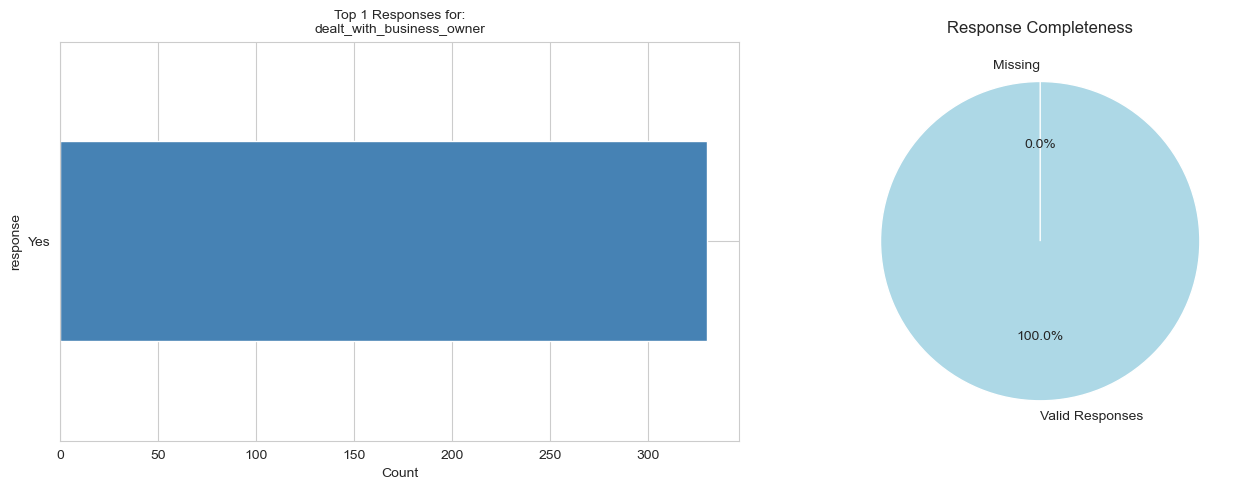


🗺️ Distribution by District:
response    Yes
district       
Aldhalea     26
Almadharba    3
Khanfir      76
Radfan       57
Sarar        11
Tuban        61
Zingibar     96


QUESTION: business_owner_difference

📊 Basic Statistics:
  Total responses: 330
  Non-null responses: 330
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 10

📈 Response Distribution:
response
Expand work                     93
added inventory                 69
Don’t know                      63
added assits                    28
No different                    25
customer service                21
improved the quality of work    10
deterioration work              10
No major different               6
Increace no. of customers        5
Name: count, dtype: int64


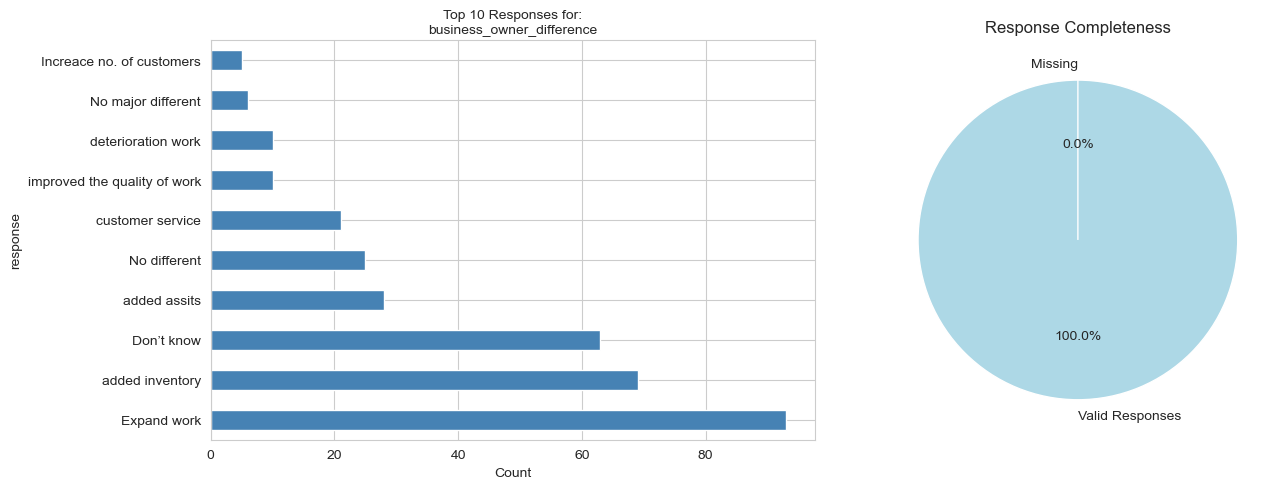


🗺️ Distribution by District:
response    Don’t know  Expand work  Increace no. of customers  No different  \
district                                                                       
Aldhalea             8            3                          0             7   
Almadharba           2            0                          0             0   
Khanfir              8           26                          1             4   
Radfan              23           11                          1             6   
Sarar                2            3                          0             0   
Tuban               10           26                          0             0   
Zingibar            10           24                          3             8   

response    No major different  added assits  added inventory  \
district                                                        
Aldhalea                     0             2                5   
Almadharba                   0             0          

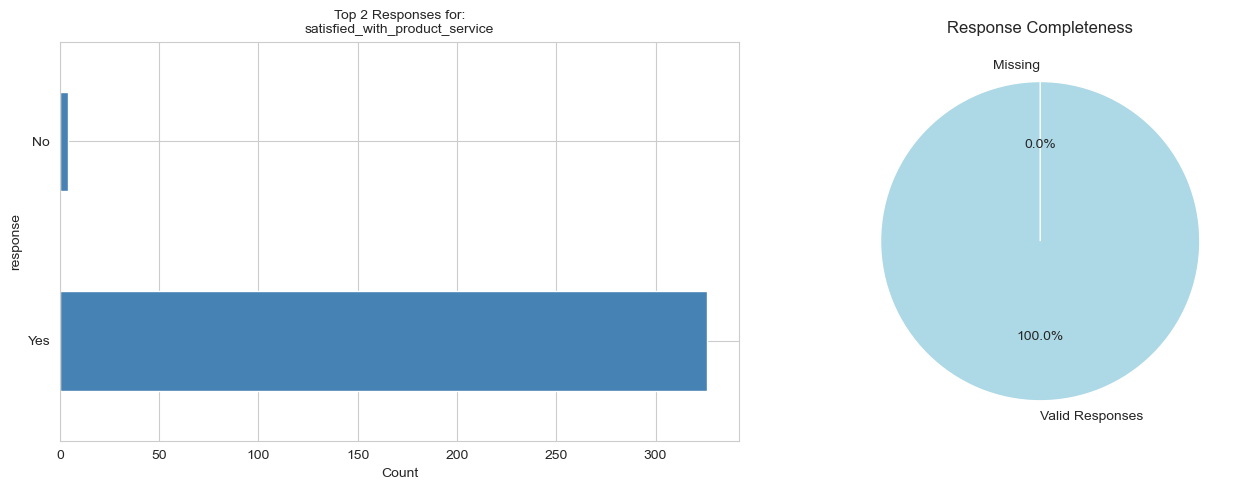


🗺️ Distribution by District:
response    No  Yes
district           
Aldhalea     1   25
Almadharba   0    3
Khanfir      0   76
Radfan       1   56
Sarar        0   11
Tuban        1   60
Zingibar     1   95


QUESTION: no_longer_access_impacted

📊 Basic Statistics:
  Total responses: 330
  Non-null responses: 330
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 3

📈 Response Distribution:
response
Yes              254
No difference     53
No                23
Name: count, dtype: int64


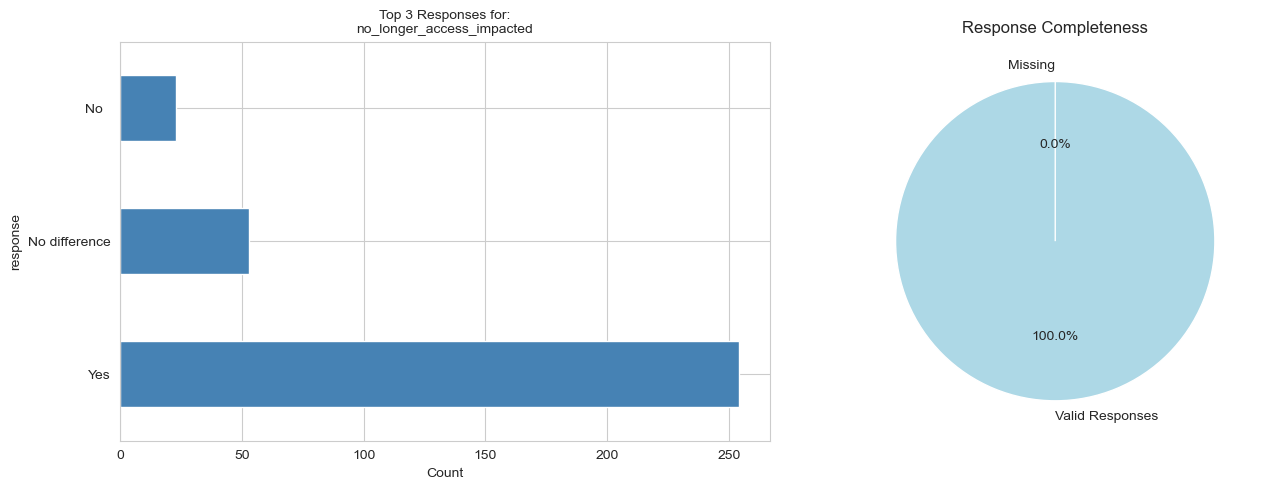


🗺️ Distribution by District:
response    No    No difference  Yes
district                            
Aldhalea       2              6   18
Almadharba     1              2    0
Khanfir        4              8   64
Radfan         7             20   30
Sarar          2              1    8
Tuban          3              6   52
Zingibar       4             10   82


QUESTION: business_vendor_help_time_money_effort

📊 Basic Statistics:
  Total responses: 330
  Non-null responses: 330
  Missing responses: 0
  Response rate: 100.0%

  Unique values: 2

📈 Response Distribution:
response
Yes    315
No      15
Name: count, dtype: int64


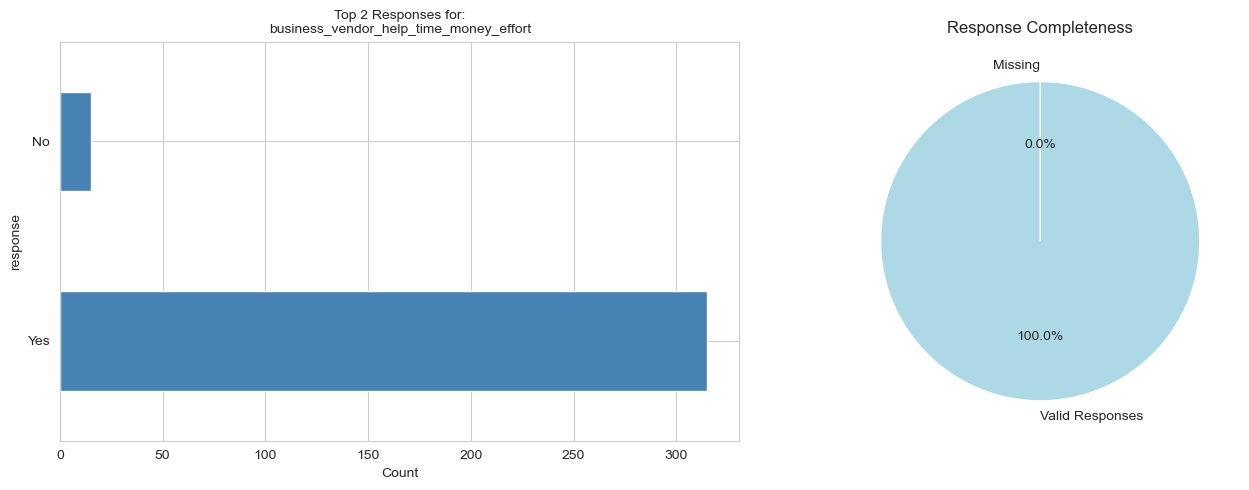


🗺️ Distribution by District:
response    No  Yes
district           
Aldhalea     0   26
Almadharba   0    3
Khanfir      1   75
Radfan       8   49
Sarar        0   11
Tuban        0   61
Zingibar     6   90




In [108]:
# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Analyze all Single Response questions
print("\n" + "#" * 80)
print("# SINGLE RESPONSE QUESTIONS - EDA")
print("#" * 80 + "\n")

for question in cust_sr_questions:
    analyze_question(cust_melted_sr, question, question_type='SR')


# # Analyze all Multiple Response questions
# print("\n" + "#" * 80)
# print("# MULTIPLE RESPONSE QUESTIONS - EDA")
# print("#" * 80 + "\n")

# for question in cust_mr_questions:
#     analyze_question(cust_melted_mr, question, question_type='MR')

Original: مرحبا بالعالم
Reshaped: ﻢﻟﺎﻌﻟﺎﺑ ﺎﺒﺣﺮﻣ


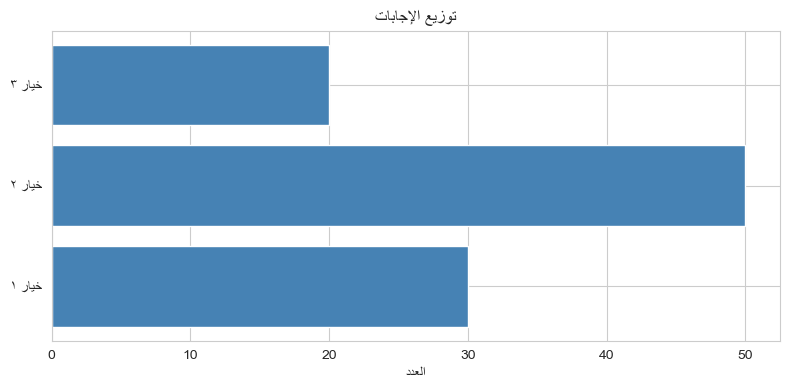

In [109]:
# Test Arabic text display
test_text = "مرحبا بالعالم"
print(f"Original: {test_text}")
print(f"Reshaped: {arabic_text(test_text)}")

# Simple plot test
plt.figure(figsize=(8, 4))
arabic_labels = [arabic_text("خيار ١"), arabic_text("خيار ٢"), arabic_text("خيار ٣")]
values = [30, 50, 20]
plt.barh(arabic_labels, values, color='steelblue')
plt.title(arabic_text("توزيع الإجابات"))
plt.xlabel(arabic_text("العدد"))
plt.tight_layout()
plt.show()